# Building an Investment Trading Strategy in Python
Created by Cordell L. Tanny, CFA, FRM, FDP
Digital Hub Insights LLC

Version: 7

Last date of revision: December 7, 2025

v7 Updates:
- Fixed all setting with copy warnings in backtest functions


This notebook and all code are the intellectual property of Digital Hub Insights LLC. All rights reserved.

[www.digitalhub-labs.com](https://)

## Summary
This notebook teaches the complete process of developing a trading strategy that rotates between the market-cap weighted S&P 500 (SPY) and the equal-weighted S&P 500 (RSP). Using rolling returns, z-scores, and volatility filters, we systematically evaluate when it is better to invest in SPY vs. RSP.

##Why It Matters
Developing a quantitative trading strategy is a critical skill for any modern investor or analyst. This notebook walks you through how to build, test, and refine a strategy that takes advantage of different market environments. The combination of z-scores, volatility filtering, and systematic backtesting lays the foundation for building real-world, adaptable strategies. You’ll learn to move from hypothesis to performance evaluation and, ultimately, optimize decision-making in portfolio management.

## Introduction

Building a successful trading or investment strategy isn't easy. Determining a good signal, or "alpha generator" as it is called is challenging in itself. And while there is no set playbook on how to test ideas, build a trading system, and deploy it, the development of a process that incorporates logic and some experience is the best place to start.

The goal of this course is to help you build this process. To do this, we will examine a potential investment strategy: When should we be invested in the equal weighted S&P 500 (RSP), or when is it better to be in the market cap weighted ETF (SPY).

**Why Compare SPY vs. RSP? What’s the Hypothesis?**

One of the key decisions in equity investing is choosing between a market-cap weighted strategy, like SPY (which tracks the S&P 500), and an equal-weighted strategy, like RSP (which also tracks the S&P 500 but allocates an equal amount to each stock regardless of size). Both of these ETFs represent the same underlying 500 companies, but the weightings of those companies are vastly different, which leads to differences in performance.

The hypothesis here is that there are periods when one strategy outperforms the other. For example, in a bullish market with strong momentum, larger-cap stocks that dominate SPY may outperform, pushing SPY ahead. Conversely, during periods of market correction or in a mean-reverting environment, smaller or mid-cap stocks, which are given more weight in RSP, could perform better. Understanding the dynamics between these two approaches and identifying signals that indicate when to be invested in either SPY or RSP is critical.

In this course, we will explore this hypothesis further by using a quantitative approach to determine when it's advantageous to be invested in either SPY or RSP.

The steps involved are:
1.   Exploratory data analysis.
2.   Determining a relationship between the two.
3.   Produce a graphic visualization of the relationship.
4.   Determine a set of trading rules.
5.   Improve the strategy with other indicators or metrics.
6.   Backtest
7.   Determine statistical significance.

In [1]:
# Install the pandas_market_calendars package
!pip install -q pandas_market_calendars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.5/127.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


If you are using openbb to retrieve prices, please make sure to uncomment the import openbb statement

In [2]:
import DHI0005_functions_udemy as mf  # make sure to use the right import for the functions file!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from datetime import datetime
from typing import List, Tuple, Optional
import warnings
import yfinance as yf

warnings.simplefilter(action='ignore', category=FutureWarning)

sns.set_theme()

## Exploratory Data Analysis (EDA)

The first steps in EDA is to retrieve and prepare the data.
We will download the prices from Yahoo! Finance

In [3]:
# Initialization
start_date = '1997-01-01'
end_date = '2024-11-30'

In [4]:
# Retrieve Prices
df_prices = mf.retrieve_prices_yf(['SPY', 'RSP'], start_date=start_date, end_date=end_date).sort_index().dropna()
df_prices.index = pd.to_datetime(df_prices.index)

df_prices.head()

[*********************100%***********************]  2 of 2 completed


Ticker,RSP,SPY
Date,,
2003-05-01,18.054909,60.609119
2003-05-02,18.391285,61.473099
2003-05-05,18.430237,61.354389
2003-05-06,18.577192,61.934731
2003-05-07,18.504587,61.591805


### Cumulative Returns
The first question we aim to answer is: Over the long run, which has performed better, SPY or RSP?

To begin, we’ll analyze the cumulative returns of both ETFs over the entire available period. Cumulative return is one of the most intuitive ways to visualize long-term performance, as it allows us to see the growth of $1 invested at the start of the period.

For this, we will use a cumulative return graph that shows the percentage change over time. This type of visualization will help us easily identify trends, periods of outperformance, and overall long-term growth between SPY (market-cap weighted) and RSP (equal-weighted). The cumulative returns are calculated by compounding the daily percentage returns of the ETFs over time.

By comparing the two lines on this graph, we can get a sense of which strategy—market-cap weighted or equal-weighted—has delivered better returns over the full period and whether there are any clear periods where one consistently outperforms the other.

Let’s plot the cumulative returns of SPY and RSP to visually explore the long-term performance of these two strategies.

In [5]:
# Cumulative Return Graphs of SPY and RSP
mf.cumulative_return_graph_plotly(df_prices.pct_change().dropna())

We can see that RSP seems to have outperformed since 2004, although there are definitely some periods where RSP did worse than SPY.

### Rolling Returns Analysis

While we now have an understanding of how SPY and RSP have performed over the long run, answering the question of whether RSP consistently outperforms SPY isn’t as straightforward. The key challenge is that the answer depends on the time period we choose. Different time horizons may lead to different conclusions, and arbitrarily picking a single time period can introduce bias.

To get around this issue, one of the best approaches is to use rolling returns. Rolling returns allow us to look at the performance of both ETFs over many different overlapping periods, giving us a fuller picture of how they’ve performed relative to each other over time. This approach helps remove bias by ensuring that all time periods within the dataset are considered equally.

The logic is simple: rather than selecting one specific time frame (e.g., 1 year, 5 years), we compute the returns over a specified window (e.g., 12 months), then "roll" that window forward one period at a time. This way, we create a series of returns for all possible time periods of that length. We can then compare the rolling returns of RSP and SPY over each window and see whether RSP has historically outperformed SPY across many different time frames.

To proceed, we will:

Calculate the rolling returns of SPY and RSP over a specified time window (e.g., 36 months, which is 3-years and is a very good window to start with).
Plot these rolling returns to visualize how each ETF has performed over various periods.
Determine the percentage of rolling periods where RSP has outperformed SPY, giving us a better sense of whether the equal-weighted strategy tends to outperform or underperform the market-cap weighted strategy over time.
By calculating the returns in this manner, we gain insight into how consistently one ETF performs better than the other across different market conditions and economic environments.

In [6]:
# Create a function for rolling returns

def rolling_returns(prices, period, frequency='D', annualize=True):
    """
    Calculate rolling returns for a given DataFrame of prices over a specified period.

    This function computes the percentage change in prices over the number of periods specified,
    which represents the rolling return. If annualize is True, the rolling returns are annualized
    based on the inferred frequency of the data points in the 'prices' DataFrame.

    Parameters:
    ----------
    prices : pd.DataFrame
        A pandas DataFrame with datetime index representing the time series data of prices.

    period : int
        The number of periods over which the rolling return should be calculated. This should
        match the frequency of the data (e.g., if monthly data, and you want 3-month rolling returns,
        period should be 3).

    annualize : bool, optional (default=True)
        If True, annualizes the rolling returns based on the frequency of the data. For daily data,
        assumes 252 trading days in a year, and for monthly data, 12 months in a year.

    Returns:
    -------
    pd.DataFrame
        A DataFrame of the same shape as 'prices', containing the rolling returns over the
        specified period. If 'annualize' is True, these returns are annualized.

    Examples:
    --------
    >>> prices = pd.DataFrame({'AAPL': [100, 105, 110, 120, 115]})
    >>> rolling_returns(prices, 2)
        AAPL
    1  0.050
    2  0.048
    3  0.091
    4 -0.042

    >>> rolling_returns(prices, 2, annualize=False)
        AAPL
    1  0.050
    2  0.048
    3  0.091
    4 -0.042
    """

    # calculate the rolling returns based on the period
    df_rolling = prices.pct_change(period).dropna()

    if annualize:
        match frequency:
            case 'D':
                periods_per_year = 252

            case 'M':
                periods_per_year = 12

        df_rolling = (1 + df_rolling) ** (periods_per_year / period) - 1

    return df_rolling


df_rolling_returns = rolling_returns(df_prices, 252*3, 'D', True)
df_rolling_returns.head()

Ticker,RSP,SPY
Date,,
2006-05-02,0.216747,0.146432
2006-05-03,0.208377,0.139616
2006-05-04,0.209425,0.141714
2006-05-05,0.210359,0.141477
2006-05-08,0.212477,0.143131


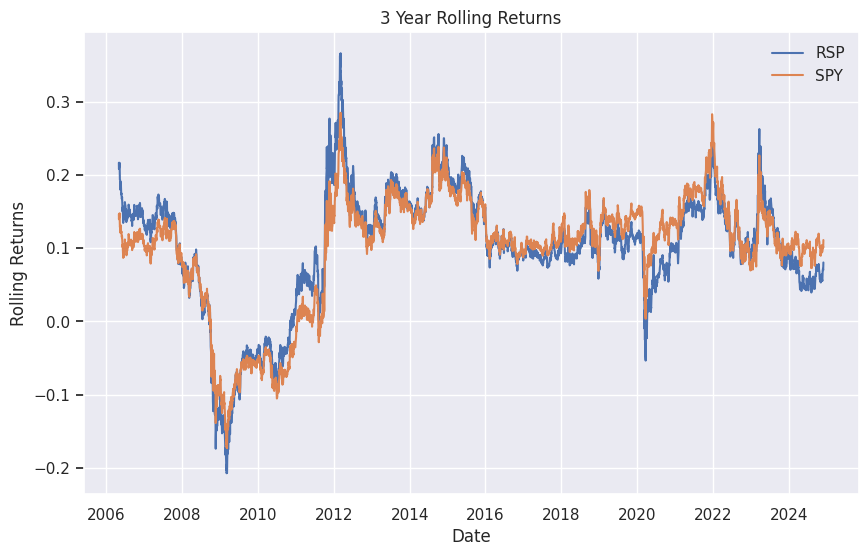

In [7]:
def plot_rolling_returns(returns, highlight_col=None, alpha=1.0, title=None):
    """
    Plot rolling returns from a DataFrame.

    Parameters:
    - df: DataFrame with rolling returns data.
    - highlight_col: Column to highlight with a different alpha value.
    - alpha: Transparency (alpha) value for all lines (default: 1.0).

    Returns:
    - None (displays the plot).
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot all columns with the specified alpha value and custom colors
    for i, col in enumerate(returns.columns):
        line_alpha = alpha if col != highlight_col else 1.0
        sns.lineplot(data=returns[col], alpha=line_alpha, ax=ax, label=col)

    ax.set_xlabel('Date')
    ax.set_ylabel('Rolling Returns')
    ax.set_title(title, loc='center')

    # Legend with no frame, black font, top left corner
    legend = plt.legend(frameon=False, loc='best')

    # Move y-axis ticks and labels to the left side
    ax.yaxis.tick_left()

    plt.show()


plot_rolling_returns(df_rolling_returns, title='3 Year Rolling Returns')

We can immediately see one main pattern: It seems that RSP outperformed on every 3-year period starting in 2006, didn;t do as well in the 2008 GFC, and then again up until around 2016. After that, SPY seems to dominate (I think we all know how to pronouce FANG and then magnificient 7!).

Let's conduct a more detailed analysis. What percent of all rolling 3-year periods did RSP outperform SPY.

In [8]:
# Rolling Return Stats
def rolling_return_stats(rolling_returns, benchmark):
    """
    Calculate statistics for rolling returns compared to a benchmark.

    Args:
    rolling_returns (pd.DataFrame): A DataFrame where each column represents the rolling returns of an asset.
    benchmark (str): The column name of the benchmark asset to compare against.

    Returns:
    pd.DataFrame: A DataFrame containing the percentage of periods each asset's return
                  was greater than the benchmark, the maximum return, and the minimum return.

    Example:
    >>> data = {
        'Fund1': [0.1, 0.2, 0.15, 0.22, 0.18],
        'Fund2': [0.12, 0.18, 0.17, 0.21, 0.19],
        'Benchmark': [0.11, 0.19, 0.16, 0.2, 0.17]
    }
    >>> rolling_returns = pd.DataFrame(data)
    >>> stats = rolling_return_stats(rolling_returns, 'Benchmark')
    >>> print(stats)
    """

    # Initialize an empty DataFrame to store statistics
    df_stats = pd.DataFrame()

    # Iterate over each column in the DataFrame to compute statistics
    for col in rolling_returns.columns:
        # Compute the percentage of periods where the return of the column is greater than the benchmark
        percent_greater = (rolling_returns[col] > rolling_returns[benchmark]).sum() / rolling_returns.shape[0]

        # Store the computed percentage in df_stats, multiplying by 100 to convert to percentage and rounding to 2 decimal places
        df_stats.loc[col, '% Periods Greater Than Benchmark'] = np.round(percent_greater * 100, 2)

    # Compute and store the maximum return for each column, rounded to 2 decimal places
    df_stats['Maximum Return (%)'] = rolling_returns.max().round(2)

    # Compute and store the minimum return for each column, rounded to 2 decimal places
    df_stats['Minimum Return (%)'] = rolling_returns.min().round(2)

    return df_stats


df_rr_stats = rolling_return_stats(df_rolling_returns.mul(100).round(2), 'SPY')
df_rr_stats


,% Periods Greater Than Benchmark,Maximum Return (%),Minimum Return (%)
RSP,49.25,36.64,-20.74
SPY,0.00,28.50,-17.31


This is a powerful table and shows why rolling returns analysis is so important. We will expand on this towards the end of the course, but you can see that it is really a 50/50 split in terms of all rolling 3-year periods. We can also see that RSP seems to be a little more volatile as it's best and worst 3-year period are more extreme than SPY.

##Spliting Data into Training and Test Sets
When building and testing trading strategies, there are a number of techniques that we can use to try and ensure that the strategy is robust and not a result of overfitting or random chance. Ultimately, you need to prove that the results you achieved aren't due to luck and that the strategy is likely to work in the future.

Normally, when we build trading strategies, we are testing and optimizing parameters. Simply determining the best set of parameters and expecting that to work in the future because it performed well in the past is a flawed approach. Of course, the backtest will look good—you optimized the parameters for historical data. But in the real world, market conditions constantly change, and nothing will remain optimal indefinitely. To deal with the false discovery problem, we need to prove statistical significance and test our strategies in ways that minimize the risk of overfitting. Below are some common methods to test a trading strategy:

1. In-sample and out-of-sample testing: This involves splitting the data into two sets: a training set that typically contains 70%-80% of the historical data, and a test set that includes the remaining data. The model is trained on the training set and then tested on the unseen test set to evaluate its performance on new data. If enough data is available, you can even reserve a third holdout set. The holdout set can be used as a final evaluation after refining the model based on training and test set results.

2. Walk-forward analysis: Walk-forward analysis is an enhanced and widely used method of performing train-test splits. It involves creating expanding windows of historical data for training and continuously re-training the model as new data becomes available. The model is tested on the next, unseen time period after each training window. The process generates a series of out-of-sample test results that can be concatenated to simulate a rolling track record. This method is particularly useful for time-series data, where maintaining chronological order is crucial.

3. Rolling period analysis: In this method, we analyze how each parameter combination performs across overlapping rolling periods, such as rolling 3-year windows. This approach allows us to evaluate a strategy’s robustness over time by seeing how it performs in different market environments. Since it is unlikely that any parameter combination will be optimal for all rolling periods, we rank combinations based on their consistency in outperforming over most rolling periods. Additionally, examining the trading results during underperforming periods helps assess the strategy's resilience and downside risk. We use monthly data in this analysis to smooth out daily noise and focus on broader trends.

We will examine the differences between the train/test split and the rolling 3-year analysis method.

Let's start with our train/test split.
Important note: You will see us split the original df_prices many times instead of just once after we have created all of the data we need. We do this to avoid repeating some steps many times and since the goal here is to teach a process. Thus, we wanted to isolate each concept. In practice, you would just do one split after creating the needed data.

Furthermore, you never want to do standardization and normalization before doing the train/test split. This would introduce look-ahead bias, one of the cardinal sins of quantitative trading. All normalization should be done on the train and test sets independently.

In [9]:
# Split the between a training set and test set
oos_date = datetime(2020, 1, 1)
df_is_prices = df_prices.loc[:oos_date]

print(df_is_prices.head())

Ticker            RSP        SPY
Date                            
2003-05-01  18.054909  60.609119
2003-05-02  18.391285  61.473099
2003-05-05  18.430237  61.354389
2003-05-06  18.577192  61.934731
2003-05-07  18.504587  61.591805


##Rolling Correlation Analysis: SPY vs RSP
**Objective**

The goal of this analysis is to investigate the relationship between SPY (a market-cap-weighted S&P 500 ETF) and RSP (an equal-weighted S&P 500 ETF). Specifically, we calculate rolling correlations over 36-month and 12-month periods to understand the stability and evolution of their relationship over time. This helps us evaluate whether the relationship exhibits consistent patterns or shifts under different market conditions, which could inform trading strategies.

**Methodology**

*Monthly Data Aggregation*: The data is resampled to monthly frequency to focus on longer-term trends and reduce noise inherent in daily returns.

*Calculate Monthly Returns:* Monthly percentage changes are calculated for SPY and RSP, which form the basis for the rolling correlation analysis.

**Rolling Correlations:**

A 36-month rolling window captures the long-term relationship between SPY and RSP, smoothing out short-term fluctuations.
A 12-month rolling window focuses on the shorter-term relationship, allowing us to identify more recent and dynamic shifts.
Interpretation of Rolling Correlations
Rolling correlation measures how closely the returns of SPY and RSP move together over a specified window. Correlations near 1 indicate a strong positive relationship, meaning the two ETFs move in tandem. Lower correlations imply periods of divergence, which might suggest opportunities to exploit differences in their performance.

In [10]:
# Ensure monthly data is used
df_monthly = df_is_prices.resample('ME').last()

# Step 1: Calculate Monthly Returns
df_monthly_returns = df_monthly.pct_change().dropna()

<Figure size 1200x600 with 0 Axes>

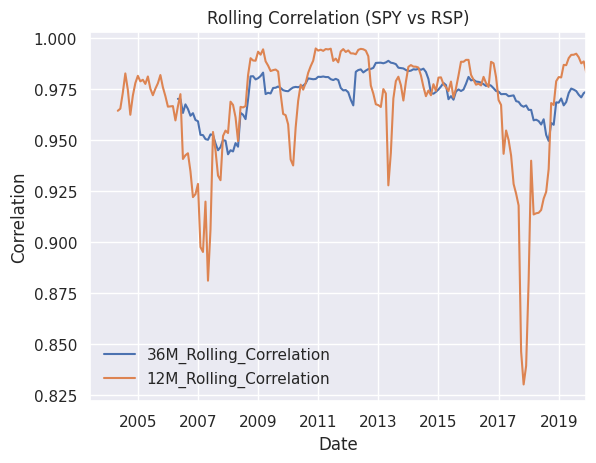

In [11]:
# Step 2: Calculate Rolling Correlation (36-month and 12-month)
df_monthly_returns['36M_Rolling_Correlation'] = df_monthly_returns['SPY'].rolling(36).corr(df_monthly_returns['RSP'])
df_monthly_returns['12M_Rolling_Correlation'] = df_monthly_returns['SPY'].rolling(12).corr(df_monthly_returns['RSP'])

# Plot Rolling Correlation
plt.figure(figsize=(12, 6))
df_monthly_returns[['36M_Rolling_Correlation', '12M_Rolling_Correlation']].plot(title='Rolling Correlation (SPY vs RSP)')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.legend(frameon=False)
plt.show()

**Analysis of Results**

The graph above shows the rolling correlations for SPY and RSP over both 36-month and 12-month periods. Key observations include:

**General Stability:**

The 36-month rolling correlation demonstrates a consistently high correlation between SPY and RSP over time, hovering close to 0.95 or above. This indicates that, over longer periods, SPY and RSP share a very strong relationship.

**Shorter-Term Variations:**

The 12-month rolling correlation shows more fluctuations compared to the 36-month window. This highlights short-term deviations in how SPY and RSP perform relative to one another.

Notable dips in the 12-month rolling correlation, particularly during periods of market stress such as the 2008 Global Financial Crisis, indicate divergence in the performance of the two ETFs. These periods could be explored further for potential trading opportunities.
Potential Trading Signals:

Periods when the 12-month correlation diverges significantly from the 36-month correlation could signal short-term anomalies that may be exploited. For instance, a sharp decline in the 12-month correlation might suggest that the equal-weighted RSP is behaving differently from the market-cap-weighted SPY, potentially due to sector rotation, changes in market breadth, or other market dynamics.


---



## Exploring Patterns in Rolling Returns
From our previous analyses, we have seen that over any 3-year period, there is an even split between whether SPY or RSP performed better. This suggests that neither consistently outperforms the other, and instead, there may be shifts or "regime flips" in performance over time. The next logical step is to investigate whether there are patterns or indicators that could help us identify when these shifts occur.

To do this, we will stick with rolling returns to capture how performance evolves over different time frames. By focusing on rolling windows, we smooth out the day-to-day volatility and can identify periods where one ETF starts to outperform the other.

But over what time window should we examine these rolling returns?

To capture different market cycles, we will explore three rolling periods:

- 21 days (approximately 1 month),

- 126 days (approximately 6 months), and

- 252 days (approximately 1 year).

By analyzing these three windows, we can compare short-, medium-, and longer-term trends in the relative performance of SPY and RSP. Importantly, since we are dealing with periods shorter than one year, we will not annualize these rolling returns.

This exploration will help us determine whether any of these rolling windows consistently highlight periods of outperformance or regime shifts, giving us a foundation for developing a potential strategy.

In [12]:
# Applying the function for SPY and RSP with different rolling periods
df_prices['SPY_Rolling_1M'] = rolling_returns(df_prices['SPY'], period=21, annualize=False)  # Approx. 1 month
df_prices['RSP_Rolling_1M'] = rolling_returns(df_prices['RSP'], period=21, annualize=False)

df_prices['SPY_Rolling_6M'] = rolling_returns(df_prices['SPY'], period=126, annualize=False)  # Approx. 6 months
df_prices['RSP_Rolling_6M'] = rolling_returns(df_prices['RSP'], period=126, annualize=False)

df_prices['SPY_Rolling_1Y'] = rolling_returns(df_prices['SPY'], period=252, annualize=False)  # Approx. 1 year
df_prices['RSP_Rolling_1Y'] = rolling_returns(df_prices['RSP'], period=252, annualize=False)

In [13]:
# Recreate the in-sample data
df_is_prices = df_prices.loc[:oos_date]
df_is_prices.tail()

Ticker,RSP,SPY,SPY_Rolling_1M,RSP_Rolling_1M,SPY_Rolling_6M,RSP_Rolling_6M,SPY_Rolling_1Y,RSP_Rolling_1Y
Date,,,,,,,,
2019-12-24,104.544724,295.233215,0.038106,0.036335,0.116467,0.098696,0.396743,0.365569
2019-12-26,104.770805,296.804871,0.035606,0.029295,0.118444,0.094165,0.336645,0.309279
2019-12-27,104.626122,296.731262,0.033009,0.026692,0.112442,0.082721,0.326132,0.295820
2019-12-30,104.264366,295.095367,0.022754,0.018820,0.096356,0.071325,0.320524,0.294616
2019-12-31,104.653267,295.812195,0.029055,0.027049,0.096164,0.076511,0.312238,0.289066


### Plotting the Rolling Returns
In this section, we calculate and plot the rolling returns for both SPY and RSP across three time windows: 1 month (21 days), 6 months (126 days), and 1 year (252 days). These rolling returns will help us observe short-, medium-, and longer-term trends in how SPY and RSP perform relative to one another. By visualizing these rolling returns, we can potentially identify patterns or periods where one ETF tends to outperform the other.

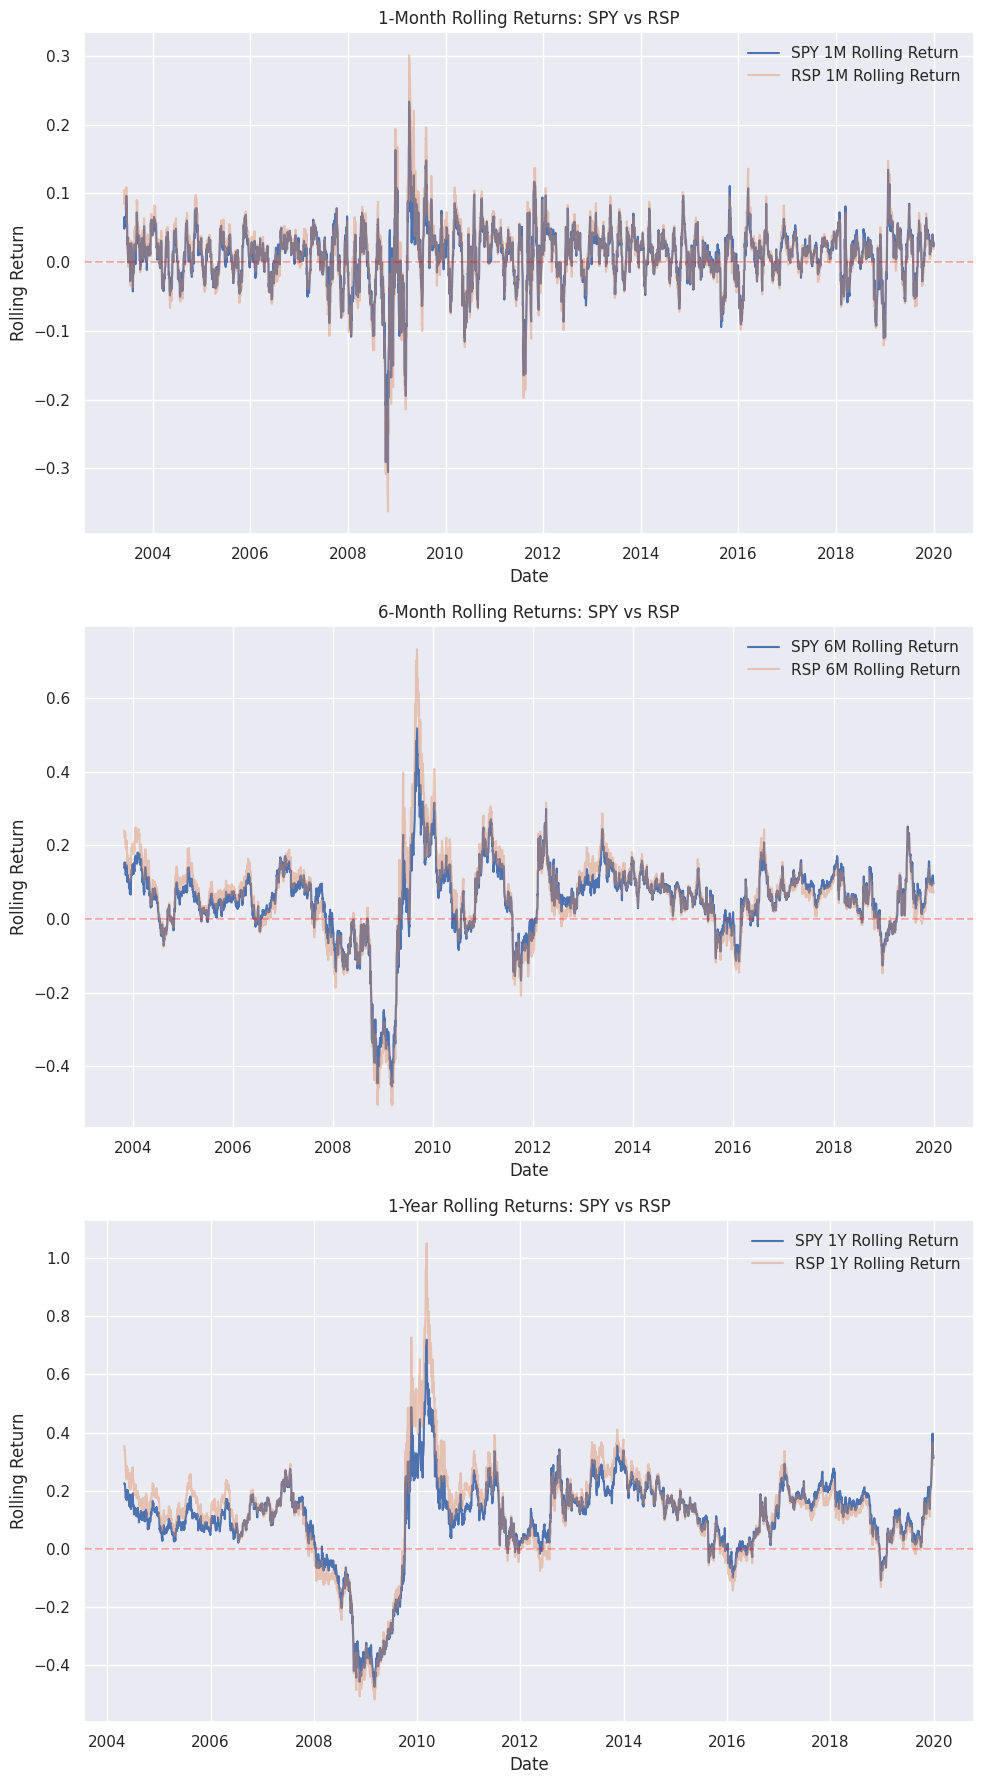

In [14]:
# Set up the figure and axes
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Plot 1-Month Rolling Returns
sns.lineplot(data=df_is_prices, x=df_is_prices.index, y='SPY_Rolling_1M', ax=axes[0], label='SPY 1M Rolling Return')
sns.lineplot(data=df_is_prices, x=df_is_prices.index, y='RSP_Rolling_1M', ax=axes[0], label='RSP 1M Rolling Return', alpha=0.4)
axes[0].set_title('1-Month Rolling Returns: SPY vs RSP')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3)

# Plot 6-Month Rolling Returns
sns.lineplot(data=df_is_prices, x=df_is_prices.index, y='SPY_Rolling_6M', ax=axes[1], label='SPY 6M Rolling Return')
sns.lineplot(data=df_is_prices, x=df_is_prices.index, y='RSP_Rolling_6M', ax=axes[1], label='RSP 6M Rolling Return', alpha=0.4)
axes[1].set_title('6-Month Rolling Returns: SPY vs RSP')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)

# Plot 1-Year Rolling Returns
sns.lineplot(data=df_is_prices, x=df_is_prices.index, y='SPY_Rolling_1Y', ax=axes[2], label='SPY 1Y Rolling Return')
sns.lineplot(data=df_is_prices, x=df_is_prices.index, y='RSP_Rolling_1Y', ax=axes[2], label='RSP 1Y Rolling Return', alpha=0.4)
axes[2].set_title('1-Year Rolling Returns: SPY vs RSP')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.3)

# Set common labels (shared customization)
for ax in axes:
    ax.set_xlabel('Date')
    ax.set_ylabel('Rolling Return')
    ax.legend(frameon=False)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

**1-Month Rolling Returns (21-day window)**

The 1-month rolling returns reflect short-term performance trends and volatility.

SPY (blue line) and RSP (orange line) frequently intersect, indicating alternating short-term leadership.

*Key Observations:*

- Global Financial Crisis (2008–2009):
Both SPY and RSP experienced extreme volatility, with sharp negative returns.
- RSP underperformed during significant drawdowns, likely due to the higher weight of smaller-cap stocks, which are more sensitive to market downturns.

*Post-Crisis Recovery (2009–2011):*

- RSP generally outperformed SPY during the recovery phase, benefiting from the broader market rally, where smaller and mid-cap stocks tend to lead.
- Later Years (2015–2020):
The returns converge more frequently, suggesting reduced divergence in short-term performance between the two indices during this period.

*Insights:*

The short-term rolling returns highlight the volatility differences between SPY and RSP.
RSP shows stronger rebounds during market recoveries but suffers greater losses during downturns, consistent with its exposure to smaller-cap stocks.

---

**6-Month Rolling Returns (126-day window)**

The second graph represents the 6-month rolling returns for SPY and RSP. Here, the performance of SPY and RSP starts to show clearer trends, with some sustained periods of divergence. For instance, during the 2008 crisis, both ETFs experienced significant drawdowns, but RSP's recovery lagged behind SPY. The medium-term returns show more prolonged periods of outperformance by either SPY or RSP, with SPY clearly leading in the post-2010 period, while RSP saw outperformance in the 2004-2008 period.

*Key Observations:*

*2008–2009 Crisis and Recovery:*
- The divergence between SPY and RSP is more pronounced, with RSP underperforming significantly during the drawdown and strongly outperforming during the recovery.

*Mid-2010s Period:*
- From 2013 to 2016, SPY and RSP exhibit more correlated rolling returns, with fewer instances of leadership shifts. This period coincides with a large-cap-led rally.

*Late 2010s (2017–2020):*
- Divergences reappear, with RSP showing slight outperformance during periods of market strength, albeit with less pronounced leadership compared to earlier years.

*Insights:*

- The medium-term perspective confirms RSP’s stronger performance during market recoveries and highlights how SPY maintains leadership during periods of market stability or large-cap outperformance.
- The reduced volatility in both indices’ rolling returns during the mid-2010s suggests a period of relatively stable market conditions dominated by large-cap stocks.

---
**1-Year Rolling Returns (252-day window)**

In the third graph, we see the 1-year rolling returns, which offer a much clearer view of the long-term trends. The sharp volatility seen in the 1-month window is significantly reduced, and the rolling 1-year returns show more gradual shifts in performance. Notably, during the 2008 crisis, RSP fell sharply behind SPY, and the divergence became very pronounced. Overall, these 1-year rolling returns help us understand long-term performance trends, including periods of mean reversion and extended outperformance by one ETF over the other.

*Key Observations:*

*Crisis and Recovery Periods:*

- During the 2008–2009 financial crisis, the underperformance of RSP is stark, followed by significant outperformance during the recovery phase.

*Post-2010 Trends:*
- From 2010 to 2016, SPY’s rolling returns often match or exceed RSP’s, particularly during the tech-driven bull market dominated by large-cap stocks.

*Late 2010s Divergences:*
- In the final years of the chart, RSP regains some leadership, with rolling returns often exceeding SPY’s during broad market rallies.

*Insights:*

- Over longer periods, RSP’s cyclicality is evident, with periods of significant outperformance (during recoveries) and underperformance (during drawdowns or large-cap-dominated rallies).
- The rolling 1-year returns suggest that leadership alternates based on market conditions, with RSP excelling in recovery and expansion phases.

---

**Summary**

- Short-term (1 month): High volatility with overlapping performance between SPY and RSP, leading to difficulty in identifying consistent outperformance.

- Medium-term (6 months): Clearer, sustained performance trends emerge, with SPY generally outperforming after 2010, but with noticeable periods of relative RSP strength.

- Long-term (1 year): The clearest picture of sustained performance trends, highlighting more extended periods of outperformance, particularly around major market events like the 2008 financial crisis and the COVID-19 recovery.

Overall, this rolling window analysis helps highlight when performance shifts occur between SPY and RSP and provides a better sense of when regime shifts are likely to happen, particularly in the 6-month and 1-year windows.
Of course, you are free to experiment with other windows!


---



###Convert the Rolling Returns to Z-Scores

**What is a Z-Score?**

A z-score is a statistical measure that describes how far away a data point is from the mean of a dataset, expressed in standard deviations. Specifically, the z-score tells us how many standard deviations a particular value is from the mean.

A z-score of 0 means the data point is exactly at the mean.
A positive z-score means the data point is above the mean, and a negative z-score means it is below the mean.
The larger the absolute value of the z-score, the further away the data point is from the mean.

**Why Are Z-Scores Valuable?**

In the context of identifying relationships between SPY and RSP, using z-scores allows us to standardize the differences in rolling returns over time. This normalization gives us a clearer picture of when the performance difference between SPY and RSP is significant, as opposed to being part of regular market fluctuations.

Standardized Insight: By converting the rolling return differences into z-scores, we gain a way to assess whether the difference is unusually large or small compared to the historical average.
Detecting Extremes: A z-score helps us detect extreme periods when the relative performance between SPY and RSP diverges significantly. In the strategy development process, identifying these extreme moments could help define when to switch between SPY and RSP to capture potential gains or avoid losses.


In practice, z-scores can be used to generate signals. For example, if the z-score for the difference in rolling returns between SPY and RSP exceeds a certain threshold, it may indicate that SPY has significantly outperformed or underperformed RSP, suggesting a potential **mean-reversion** opportunity or **momentum** play.

And this is really what we want to isolate: periods of momentum and mean-reveion. These are 2 of the most common trading strategies out there.

**Why Use Expanding Z-Scores?**

Expanding z-scores are used to prevent look-ahead bias and data leakage by ensuring that only information available up to the current point in time is incorporated into the calculations. Unlike rolling z-scores, which use a fixed-length window, expanding z-scores dynamically include all historical data up to the given point. This approach aligns with real-world trading, where future data is unavailable, ensuring the integrity and robustness of the analysis.

In [15]:
# Look at the expanding z-scores of the differences in rolling returns

# Calculate the rolling return differences
df_prices['Rolling_1M_Diff'] = df_prices['SPY_Rolling_1M'] - df_prices['RSP_Rolling_1M']
df_prices['Rolling_6M_Diff'] = df_prices['SPY_Rolling_6M'] - df_prices['RSP_Rolling_6M']
df_prices['Rolling_1Y_Diff'] = df_prices['SPY_Rolling_1Y'] - df_prices['RSP_Rolling_1Y']

# Define a function to calculate expanding z-scores up to each point
def expanding_zscore(series):
    expanding_mean = series.expanding().mean()
    expanding_std = series.expanding().std()
    return (series - expanding_mean) / expanding_std

# Apply the expanding z-score calculation to each rolling difference
df_prices['Rolling_1M_Diff_Z'] = expanding_zscore(df_prices['Rolling_1M_Diff'])
df_prices['Rolling_6M_Diff_Z'] = expanding_zscore(df_prices['Rolling_6M_Diff'])
df_prices['Rolling_1Y_Diff_Z'] = expanding_zscore(df_prices['Rolling_1Y_Diff'])

# Ensure z-scores only start from the first valid window of data (e.g., for 1Y diff, from April 30, 2007)
# This removes NaNs from the initial expanding window calculations
df_prices['Rolling_1M_Diff_Z'] = df_prices['Rolling_1M_Diff_Z'][df_prices['Rolling_1M_Diff'].notna()]
df_prices['Rolling_6M_Diff_Z'] = df_prices['Rolling_6M_Diff_Z'][df_prices['Rolling_6M_Diff'].notna()]
df_prices['Rolling_1Y_Diff_Z'] = df_prices['Rolling_1Y_Diff_Z'][df_prices['Rolling_1Y_Diff'].notna()]


Why did we need those last three lines?

1. Align Z-Scores with Valid Data Only:

- These lines ensure that Rolling_1M_Diff_Z, Rolling_6M_Diff_Z, and Rolling_1Y_Diff_Z contain valid z-scores only for the periods where Rolling_1M_Diff, Rolling_6M_Diff, and Rolling_1Y_Diff are not NaN.

2. Remove Residual NaNs in Z-Scores:

- Since the expanding_zscore function may propagate NaN values to all subsequent calculations, this step removes any rows with invalid z-scores caused by the initial NaN values in the rolling difference columns.

3. Prevent Misaligned Data:

- Without this step, there’s a risk of using NaN z-scores in further analysis, which can lead to erroneous results or difficulty in aligning data for subsequent calculations or modeling.

ok, but then why diod we do this after calculating the expanding z-scores and not before?

- While the expanding_zscore function handles the cumulative mean and standard deviation, it does not inherently address the issue of missing or invalid data in the input series. The last three lines enforce that the output `*_Z` columns only retain valid rows corresponding to valid input data.

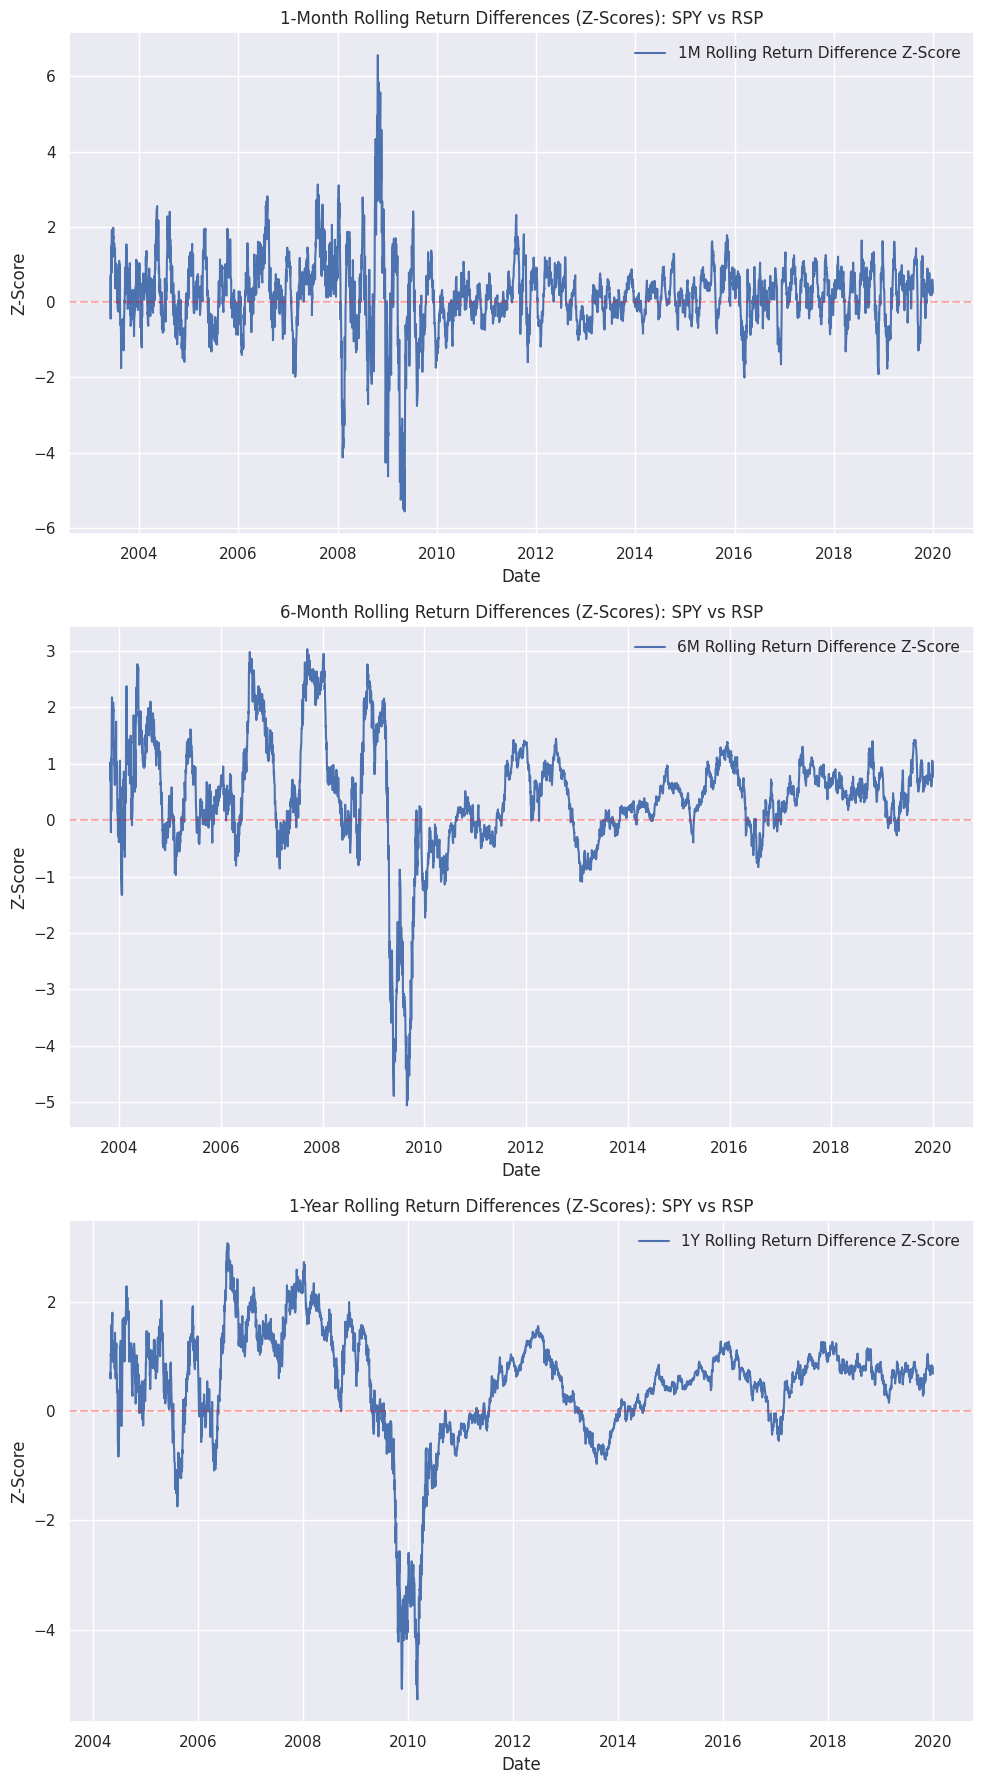

In [16]:
# Isolate the in-sample prices, which now contain the expanding z-score differences
df_is_prices = df_prices.loc[:oos_date]

# Set up the figure and axes
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Plot 1-Month Rolling Return Z-Scores
sns.lineplot(data=df_is_prices, x=df_is_prices.index, y='Rolling_1M_Diff_Z', ax=axes[0],
             label='1M Rolling Return Difference Z-Score')
axes[0].set_title('1-Month Rolling Return Differences (Z-Scores): SPY vs RSP')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3)

# Plot 6-Month Rolling Return Z-Scores
sns.lineplot(data=df_is_prices, x=df_is_prices.index, y='Rolling_6M_Diff_Z', ax=axes[1],
             label='6M Rolling Return Difference Z-Score')
axes[1].set_title('6-Month Rolling Return Differences (Z-Scores): SPY vs RSP')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)

# Plot 1-Year Rolling Return Z-Scores
sns.lineplot(data=df_is_prices, x=df_is_prices.index, y='Rolling_1Y_Diff_Z', ax=axes[2],
             label='1Y Rolling Return Difference Z-Score')
axes[2].set_title('1-Year Rolling Return Differences (Z-Scores): SPY vs RSP')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.3)

# Set common labels
for ax in axes:
    ax.set_xlabel('Date')
    ax.set_ylabel('Z-Score')
    ax.legend(frameon=False)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

**Analysis of Expanding Z-Scores for Rolling Return Differences**

*1-Month Rolling Return Differences Z-Scores*

- Observation: The 1-month z-scores exhibit significant volatility, with extreme spikes during periods of market turbulence, such as the 2008 financial crisis. The z-scores frequently oscillate between positive and negative ranges, with occasional spikes exceeding ±4 or ±5.
- Implication: These short-term fluctuations indicate frequent reversals in relative performance between SPY and RSP. A potential trading strategy could involve using z-score thresholds (e.g., ±2) to signal mean-reversion trades. For example:
 - Buy SPY: When the z-score is less than -2, signaling underperformance of SPY relative to RSP.
 - Buy RSP: When the z-score exceeds +2, signaling outperformance of SPY relative to RSP and potential reversal.

*6-Month Rolling Return Differences Z-Scores*

- Observation: The 6-month z-scores are smoother compared to the 1-month z-scores but still display notable variability, particularly around major market events. Z-scores occasionally exceed ±3 during periods of heightened volatility but are more contained than the 1-month data.
- Implication: The smoother trends suggest the 6-month z-scores could be more reliable for mid-term trading signals. Thresholds (e.g., ±1.5 or ±2) might be used to capture broader performance divergences, avoiding noise seen in shorter-term z-scores. This timeframe may be more suitable for swing or position traders looking to capitalize on medium-term relative movements.

*1-Year Rolling Return Differences Z-Scores*

- Observation: The 1-year z-scores are the smoothest of the three plots, reflecting longer-term trends in the relative performance of SPY and RSP. Significant divergence occurred during the financial crisis, with z-scores exceeding ±4, but subsequent periods show z-scores generally within ±2.
- Implication: Longer-term z-scores could be used to identify more sustained momentum or mean-reversion opportunities. A potential strategy could involve:
 - Momentum Play: If z-scores exceed ±2 for a prolonged period, the strategy could hold the outperforming asset.
 - Mean-Reversion Play: Enter positions when z-scores cross below ±1.5, signaling a potential reversal toward the mean.

*Key Insights for Strategy Development*

- The 1-month z-scores are highly volatile and may be suitable for high-frequency or tactical trading strategies.
- The 6-month z-scores offer a balance between signal reliability and responsiveness to market changes, ideal for mid-term strategies.
- The 1-year z-scores highlight longer-term trends and are best suited for strategic, lower-frequency trades.

By defining thresholds for positive and negative z-scores (e.g., ±1.5 or ±2) and testing them across different timeframes, we can identify optimal points for switching between SPY and RSP. This approach could blend momentum and mean-reversion strategies, depending on the direction and magnitude of the z-scores.

**Before we proceed, let’s go through the process for developing the trading strategy:**

1.	Demonstrate the backtesting code.
2.	Select an arbitrary rolling z-score window and threshold to demonstrate the backtest on in-sample data.
3.	Look at the positions over time.
4.	Add a volatility overlay to improve results.
5.	Code a new backtest function to handle the volatility overlay.
6.	Run the new backtest on the same set of random parameters to show the difference.
Once we have this process down, we can move onto a grid search to visualize the results of many different parameter combinations, and then select one to test out of sample.


### Adding Columns for Daily Returns
Before we move onto the backtest, we need to calculate the daily returns for both SPY and RSP.

In [17]:
# Calculate the daily returns
df_prices['SPY_Return'] = df_prices['SPY'].pct_change().fillna(0)
df_prices['RSP_Return'] = df_prices['RSP'].pct_change().fillna(0)

And then lastly, prepare the final in-sample and out of sample sets


In [18]:
# Recreate the training and test set data
df_is_prices = df_prices.loc[:oos_date]
df_is_prices.tail()

Ticker,RSP,SPY,SPY_Rolling_1M,RSP_Rolling_1M,SPY_Rolling_6M,RSP_Rolling_6M,SPY_Rolling_1Y,RSP_Rolling_1Y,Rolling_1M_Diff,Rolling_6M_Diff,Rolling_1Y_Diff,Rolling_1M_Diff_Z,Rolling_6M_Diff_Z,Rolling_1Y_Diff_Z,SPY_Return,RSP_Return
Date,,,,,,,,,,,,,,,,
2019-12-24,104.544724,295.233215,0.038106,0.036335,0.116467,0.098696,0.396743,0.365569,0.001770,0.017771,0.031174,0.233151,0.711431,0.844690,0.000031,0.000693
2019-12-26,104.770805,296.804871,0.035606,0.029295,0.118444,0.094165,0.336645,0.309279,0.006311,0.024279,0.027366,0.599177,0.898845,0.771352,0.005323,0.002163
2019-12-27,104.626122,296.731262,0.033009,0.026692,0.112442,0.082721,0.326132,0.295820,0.006317,0.029721,0.030312,0.599495,1.055473,0.827790,-0.000248,-0.001381
2019-12-30,104.264366,295.095367,0.022754,0.018820,0.096356,0.071325,0.320524,0.294616,0.003934,0.025031,0.025908,0.407352,0.920041,0.743010,-0.005513,-0.003458
2019-12-31,104.653267,295.812195,0.029055,0.027049,0.096164,0.076511,0.312238,0.289066,0.002006,0.019653,0.023173,0.251824,0.764857,0.690301,0.002429,0.003730



---

## Backtest 1: Using the Z-Score Threshold Over a Chosen Window

The first backtest function will determine what position we are on each day, and then use that day's return as our strategy return. Meaning, if our position is SPY for a given day, the strategy return for that day will be the daily return of SPY.

Some things to conider in this backtest function:
1. We evaluate the z-scores at the end of each day. If we exceed the threshold, then it is the next day where the position changes because we would trade the next day; we can't trade after the market closes and use that day's return! This is why we shift the position column down 1 row.
2. We need to provide an initial position since it is likely the first z-score won't exceed a threshold and would return an NaN. We can look at the z-score charts above, and assess the current direction of the plot to determine the likely position at that time. For example, if you look at the one-month plot, you will see the line starts below zero and is trending up. We can infer that we would be in SPY.
3. In reality this is not the best backtest as you need to simulate the buying and selling. You normally cannot just take the daily return and assume that's what you would have recevied. This would assume you earned all dividends which you likely wouldn't. And it occurs the bid-ask spread you would have to deal with when buyng and selling. However for the purposes of this course, it is more than sufficient to illustrate the process. Furthermore, the startegies don't trade very often, so it isn't as much of an issue.


In [21]:
def backtest_zscore_strategy_with_benchmark(df: pd.DataFrame, z_col: str, threshold: float,
                                         spy_return_col: str, rsp_return_col: str,
                                         benchmark_return_col: str = None, initial_pos: str = None) -> pd.DataFrame:
    """
    Backtests a strategy based on rolling z-score differentials between SPY and RSP,
    and compares it with a benchmark. Defaults to SPY_Return if no benchmark is provided.

    Parameters:
    - df: pd.DataFrame, the dataframe containing returns, z-scores, and benchmark returns
    - z_col: str, the column name for the rolling z-score (e.g., 'Rolling_1M_Diff_Z')
    - threshold: float, the z-score threshold for entering positions
    - spy_return_col: str, the column name for SPY daily returns
    - rsp_return_col: str, the column name for RSP daily returns
    - benchmark_return_col: str, the column name for the benchmark's daily returns (default: SPY_Return)
    - initial_pos: str, the initial position ("SPY" or "RSP") to use if the initial z-score does not exceed thresholds

    Returns:
    - pd.DataFrame with the strategy returns, benchmark returns, and cumulative returns.
    """
    # If no benchmark is provided, use SPY_Return as the default benchmark
    if benchmark_return_col is None:
        benchmark_return_col = spy_return_col

    # Create an explicit copy after dropping NaNs to work on a fresh DataFrame
    # Drop rows where the z-score is NaN (since we cannot trade without a valid z-score)
    df_copy = df.dropna(subset=[z_col]).copy()

    # Create a new column for the strategy position
    df_copy.loc[:, 'Position'] = np.nan # Use .loc for assignment

    # Define the strategy logic:
    # Long RSP when z-score > threshold
    df_copy.loc[df_copy[z_col] > threshold, 'Position'] = 'RSP'

    # Long SPY when z-score < -threshold
    df_copy.loc[df_copy[z_col] < -threshold, 'Position'] = 'SPY'

    # Check if the initial position is NaN (i.e., z-score does not exceed either threshold initially)
    if pd.isna(df_copy['Position'].iloc[0]):
        if initial_pos is None:
            raise ValueError("Please provide an initial position (SPY or RSP) as the z-score does not exceed thresholds at the beginning.")
        # Use .loc for single-value assignment on the copy
        df_copy.loc[df_copy.index[0], 'Position'] = initial_pos

    # Use .loc with fillna and ffill on the entire column of the copy
    df_copy.loc[:, 'Position'] = df_copy['Position'].fillna(method='ffill')

    # Use .loc with shift on the entire column of the copy
    # Shift the position column down by 1 to avoid lookahead bias
    df_copy.loc[:, 'Position'] = df_copy['Position'].shift(1)

    # Drop the rows where the position is still NaN after shifting
    df_copy = df_copy.dropna(subset=['Position'])

    # Use .loc for calculating Strategy_Return
    # Calculate the daily strategy returns based on position
    df_copy.loc[:, 'Strategy_Return'] = np.where(df_copy['Position'] == 'RSP',
                                                df_copy[rsp_return_col],
                                                df_copy[spy_return_col])

    # Use .loc for calculating Cumulative Returns
    # Replace any remaining NaN values in the strategy returns with 0
    df_copy.loc[:, 'Strategy_Return'] = df_copy['Strategy_Return'].fillna(0)

    # Calculate cumulative returns for the strategy
    df_copy.loc[:, 'Cumulative_Strategy_Return'] = (1 + df_copy['Strategy_Return']).cumprod() - 1

    # Calculate cumulative returns for the benchmark
    df_copy.loc[:, 'Cumulative_Benchmark_Return'] = (1 + df_copy[benchmark_return_col]).cumprod() - 1

    return df_copy[['Position', 'Strategy_Return', 'Cumulative_Strategy_Return',
                    benchmark_return_col, 'Cumulative_Benchmark_Return']]

In [22]:
z_score_window = '1M'

# Example for 1-month rolling z-scores with a threshold of 2
# If no benchmark is provided, it defaults to SPY_Return as the benchmark
result_with_default_benchmark = backtest_zscore_strategy_with_benchmark(df_is_prices,
                                                                        f'Rolling_{z_score_window}_Diff_Z',
                                                                        threshold=1.5,
                                                                        spy_return_col='SPY_Return',
                                                                        rsp_return_col='RSP_Return',
                                                                        initial_pos='SPY')


cumulative_strategy_return = result_with_default_benchmark["Cumulative_Strategy_Return"].iloc[-1]
cumulative_benchmark_return = result_with_default_benchmark["Cumulative_Benchmark_Return"].iloc[-1]

print(f'Cumulative Strategy Return: {np.round(result_with_default_benchmark["Cumulative_Strategy_Return"].iloc[-1] * 100 , 2)}')
print(f'Cumulative Benchmark Return: {np.round(result_with_default_benchmark["Cumulative_Benchmark_Return"].iloc[-1] * 100 , 2)}')
print(f'Outperformance: {np.round((cumulative_strategy_return - cumulative_benchmark_return) * 100, 2)}')

Cumulative Strategy Return: 410.88
Cumulative Benchmark Return: 358.86
Outperformance: 52.02


In [23]:
mf.cumulative_return_graph_plotly(result_with_default_benchmark[['Strategy_Return', 'SPY_Return']])

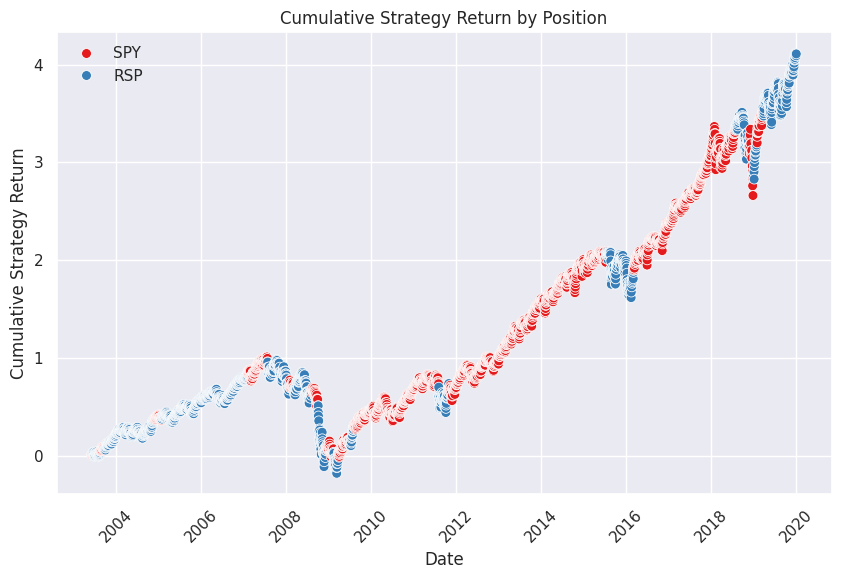

In [24]:
# Generate a plot to show the position over time.
# Create the scatter plot using seaborn
# Explicitly reset the index and name the column 'Date'
df_long = result_with_default_benchmark.reset_index().rename(columns={'index': 'Date'})

# Melt the dataframe into long form
df_long = pd.melt(df_long, id_vars=['Date', 'Position'], value_vars=['Cumulative_Strategy_Return'],
                  var_name='Return_Type', value_name='Cumulative_Return')


# Create the scatter plot using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_long, x='Date', y='Cumulative_Return', hue='Position', palette='Set1', s=50)

plt.title('Cumulative Strategy Return by Position')
plt.xlabel('Date')
plt.ylabel('Cumulative Strategy Return')
plt.legend(frameon=False)
plt.xticks(rotation=45)
plt.show()

## Backtest 2: Adding a Volatility Overlay
In this version of the backtest, we incorporate a volatility overlay by introducing thresholds that trigger a switch to cash when exceeded. The rationale for this enhancement includes:

1. Mitigating Extreme Downside Risk:

- High volatility often coincides with market stress and increased uncertainty. By moving to cash during these periods, the strategy avoids participating in potentially large drawdowns, thereby preserving capital.

2. Enhancing Risk-Adjusted Returns:

- Switching to cash during high-volatility periods smoothens the return profile of the strategy, reducing overall portfolio volatility. This improves risk-adjusted performance metrics such as the Sharpe and Sortino ratios.

3. Improved Stability Across Market Regimes:

- A volatility overlay ensures the strategy adapts to changing market conditions. During risk-off or turbulent periods, cash acts as a safe harbor, providing stability to the overall portfolio.

4. Preserving Optionality:

- Moving to cash during high volatility periods preserves liquidity and optionality, allowing the strategy to reinvest efficiently when market conditions stabilize.

This addition is a critical refinement to the strategy, as it prioritizes downside protection while still enabling participation in market growth during more stable periods. By actively managing risk through a volatility-based framework, the strategy becomes more robust and resilient to adverse market conditions.

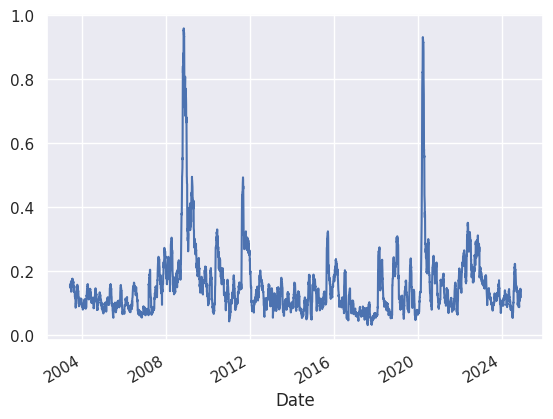

In [25]:
# Add a column for rolling volatility of SPY (20-day rolling window, annualized)
df_prices['SPY_Rolling_Volatility'] = df_prices['SPY_Return'].rolling(window=20).std().mul(np.sqrt(252))

# plot the tolling volatility
df_prices['SPY_Rolling_Volatility'].plot()
plt.show()

We can see many spikes in the rolling volatility. We can also see what looks like a normal range between 10% and 20% and periods of high volatility that go above 20%. We will address setting the high risk regime threshold shortly.

In [26]:
def backtest_zscore_strategy_with_volatility(df: pd.DataFrame, z_col: str, threshold: float,
                                             spy_return_col: str, rsp_return_col: str,
                                             volatility_col: str,
                                             high_vol_threshold: float = 0.26, low_vol_threshold: float = 0.24,
                                             benchmark_return_col: str = None, initial_pos: str = None,
                                             plot=False) -> pd.DataFrame:
    """
    Backtests a strategy based on rolling z-score differentials between SPY and RSP, incorporates a volatility filter
    with tolerance bands, and compares it with a benchmark. Defaults to SPY_Return if no benchmark is provided.
    ...
    """
    # If no benchmark is provided, use SPY_Return as the default benchmark
    if benchmark_return_col is None:
        benchmark_return_col = spy_return_col

    # Drop rows where the z-score is NaN and create an explicit, independent copy to modify
    df_copy = df.dropna(subset=[z_col]).copy()

    # Create a new column for the strategy position using .loc
    df_copy.loc[:, 'Position'] = np.nan

    # Define the strategy logic:
    # Long RSP when z-score > threshold
    df_copy.loc[df_copy[z_col] > threshold, 'Position'] = 'RSP'

    # Long SPY when z-score < -threshold
    df_copy.loc[df_copy[z_col] < -threshold, 'Position'] = 'SPY'

    # Set initial position if the first z-score does not exceed either threshold
    if pd.isna(df_copy['Position'].iloc[0]):
        if initial_pos is None:
            raise ValueError("Please provide an initial position (SPY or RSP) as the z-score does not exceed thresholds at the beginning.")
        # Set the initial position using .loc to target the index
        df_copy.loc[df_copy.index[0], 'Position'] = initial_pos

    # Fill forward the position (stay in the last chosen ETF until new signal) using .loc
    df_copy.loc[:, 'Position'] = df_copy['Position'].fillna(method='ffill')

    # Apply the volatility filter:
    in_cash = df_copy.iloc[0][volatility_col] > high_vol_threshold
    position_col_index = df_copy.columns.get_loc('Position')

    for i in range(1, len(df_copy)):
        vol = df_copy.iloc[i][volatility_col]

        # If we're in cash, stay in cash until volatility drops below the low_vol_threshold
        if in_cash:
            if vol < low_vol_threshold:
                in_cash = False  # Reenter the market
        else:
            if vol > high_vol_threshold:
                in_cash = True  # Move to cash

        # Update the position to "Cash" if we're still in cash
        # This is where the original code had an assignment that could trigger the warning.
        # We use .loc to update the specific cell on the copy.
        if in_cash:
            # Get the index of the current row and use .loc for assignment
            current_index = df_copy.index[i]
            df_copy.loc[current_index, 'Position'] = 'Cash'

    # Shift the position column down by 1 to avoid lookahead bias using .loc
    df_copy.loc[:, 'Position'] = df_copy['Position'].shift(1)

    # Drop rows where the position is still NaN after shifting
    df_copy = df_copy.dropna(subset=['Position'])

    # Calculate the daily strategy returns based on position using .loc
    df_copy.loc[:, 'Strategy_Return'] = np.where(df_copy['Position'] == 'RSP', df_copy[rsp_return_col],
                                                 np.where(df_copy['Position'] == 'SPY', df_copy[spy_return_col], 0))

    # Set return to 0 for cash days using .loc
    df_copy.loc[:, 'Strategy_Return'] = np.where(df_copy['Position'] == 'Cash', 0, df_copy['Strategy_Return'])

    # Replace any remaining NaN values in the strategy returns with 0 using .loc
    df_copy.loc[:, 'Strategy_Return'] = df_copy['Strategy_Return'].fillna(0)

    # Calculate cumulative returns for the strategy using .loc
    df_copy.loc[:, 'Cumulative_Strategy_Return'] = (1 + df_copy['Strategy_Return']).cumprod() - 1

    # Assignment to an iloc slice of SPY_Return is removed as it's not strictly necessary for backtesting
    # and was a source of warning. If the benchmark return column needs a zero for the first day,
    # it's safer to ensure that before the copy is made or handle the return calculation carefully.

    # Calculate cumulative returns for the benchmark using .loc
    df_copy.loc[:, 'Cumulative_Benchmark_Return'] = (1 + df_copy[benchmark_return_col]).cumprod() - 1


    # The plotting code is outside the scope of the warnings but is included for completeness.
    if plot:
        import matplotlib.pyplot as plt
        # Plot the volatility alongside the positions (Cash vs Invested)
        plt.figure(figsize=(10, 6))
        plt.plot(df_copy.index, df_copy[volatility_col], label='SPY Rolling Volatility', color='blue')
        plt.axhline(y=high_vol_threshold, color='red', linestyle='--', label=f'High Vol Threshold ({high_vol_threshold})')
        plt.axhline(y=low_vol_threshold, color='green', linestyle='--', label=f'Low Vol Threshold ({low_vol_threshold})')

        # Highlight the areas when we are in cash
        cash_days = df_copy[df_copy['Position'] == 'Cash'].index
        for cash_day in cash_days:
            plt.axvline(x=cash_day, color='orange', linestyle=':', label='In Cash' if cash_day == cash_days[0] else "")

        plt.title('Volatility and Strategy Positioning')
        plt.xlabel('Date')
        plt.ylabel('Volatility (Annualized)')
        plt.legend(frameon=False)
        plt.show()

    return df_copy[['Position', 'Strategy_Return', 'Cumulative_Strategy_Return',
                    benchmark_return_col, 'Cumulative_Benchmark_Return', volatility_col]]

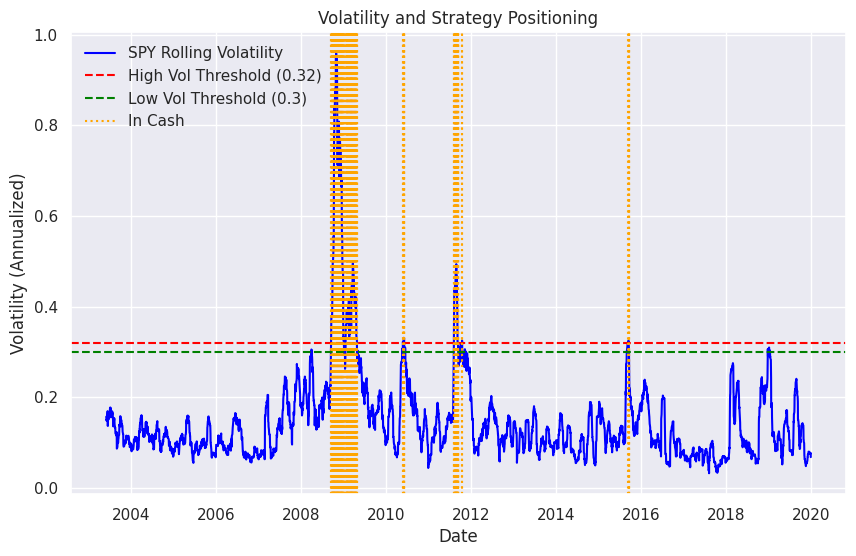

Cumulative Strategy Return: 578.67
Cumulative Benchmark Return: 358.86
Outperformance: 219.81


In [27]:
df_is_prices = df_prices.loc[:oos_date]
z_score_window = '1M'

# Example for 1-month rolling z-scores with a threshold of 1.5, high volatility threshold of 32%, low threshold of 30%
result_with_vol_filter = backtest_zscore_strategy_with_volatility(df_is_prices,
                                                                  f'Rolling_{z_score_window}_Diff_Z',
                                                                  threshold=1.5,
                                                                  spy_return_col='SPY_Return',
                                                                  rsp_return_col='RSP_Return',
                                                                  volatility_col='SPY_Rolling_Volatility',
                                                                  high_vol_threshold=0.32,
                                                                  low_vol_threshold=0.30,
                                                                  plot=True,
                                                                  initial_pos='SPY')

cumulative_strategy_return = result_with_vol_filter["Cumulative_Strategy_Return"].iloc[-1]
cumulative_benchmark_return = result_with_vol_filter["Cumulative_Benchmark_Return"].iloc[-1]

print(f'Cumulative Strategy Return: {np.round(cumulative_strategy_return * 100 , 2)}')
print(f'Cumulative Benchmark Return: {np.round(cumulative_benchmark_return * 100 , 2)}')
print(f'Outperformance: {np.round((cumulative_strategy_return - cumulative_benchmark_return) * 100, 2)}')

## Rolling Performance Metrics
**Introduction to Rolling Performance Metrics**

In evaluating the performance of a trading strategy, it’s critical to go beyond cumulative returns and examine rolling performance metrics. These metrics allow us to assess the strategy’s consistency, resilience, and risk-adjusted returns over time. By analyzing performance in smaller, overlapping windows, we can identify periods of outperformance or underperformance relative to the benchmark and better understand the dynamics of the strategy under varying market conditions.

This analysis focuses on evaluating rolling annualized returns, Sharpe ratios, and drawdowns. These measures highlight the strategy’s strengths and weaknesses, helping refine parameters and build confidence in its robustness over different time frames.


---
**Steps/Process**

1. Convert to Monthly Returns:

- Daily returns are converted to monthly returns by resampling and compounding.
- This step ensures smoother data and focuses on long-term trends rather than short-term fluctuations.
- These monthly returns serve as the foundation for calculating rolling metrics.

2. Calculate Rolling Annualized Returns:

- Using a 36-month (3-year) window, rolling annualized returns are computed to identify how the strategy performs over time.
- This step helps quantify whether the strategy consistently delivers strong returns compared to the benchmark.

3. Analyze Key Statistics:

- Rolling return statistics, such as the percentage of periods with returns greater than the benchmark, maximum return, and minimum return, are calculated.
- These provide a summary of the strategy's historical performance consistency and potential downside risk.

4. Rolling Sharpe Ratio and Drawdowns:

- The rolling Sharpe ratio evaluates risk-adjusted returns over a 36-month window.
- Rolling maximum drawdown identifies the largest declines in portfolio value within the window.
- These metrics provide deeper insight into the strategy's risk management and reward potential over time.



In [28]:
# Extract strategy and benchmark returns as separate Series
strategy_returns = result_with_vol_filter['Strategy_Return']
benchmark_returns = result_with_vol_filter['SPY_Return']

# Convert daily returns to monthly returns by resampling and compounding
monthly_strategy_returns = strategy_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
monthly_benchmark_returns = benchmark_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)

df_monthly_returns = pd.concat([monthly_strategy_returns, monthly_benchmark_returns], axis=1)
df_monthly_returns.head()

,Strategy_Return,SPY_Return
Date,,
2003-06-30,0.002724,0.002381
2003-07-31,0.023535,0.018027
2003-08-31,0.041370,0.020626
2003-09-30,-0.005831,-0.010906
2003-10-31,0.069237,0.053527


In [29]:
def calculate_rolling_annualized_return(returns: pd.Series, window: int = 36) -> pd.Series:
    """
    Calculate the rolling annualized return over a specified window.

    Parameters:
    - returns: A pandas Series of monthly returns (e.g., 0.02 for 2%).
    - window: The rolling window size in months (default is 36 for 3 years).

    Returns:
    - A pandas Series of rolling annualized returns.
    """
    # Geometrically link the returns over the rolling window
    compounded_return = (1 + returns).rolling(window=window).apply(lambda x: np.prod(x) - 1, raw=True)

    # Annualize the returns
    annualized_return = (1 + compounded_return) ** (12 / window) - 1
    return annualized_return


df_rr_is = calculate_rolling_annualized_return(df_monthly_returns, 36)
df_rr_is


,Strategy_Return,SPY_Return
Date,,
2003-06-30,NaN,NaN
2003-07-31,NaN,NaN
2003-08-31,NaN,NaN
2003-09-30,NaN,NaN
2003-10-31,NaN,NaN
...,...,...
2019-08-31,0.127079,0.125574
2019-09-30,0.139210,0.132806
2019-10-31,0.150552,0.147764


In [30]:
df_rr_stats_is = rolling_return_stats(df_rr_is.mul(100).round(2), 'SPY_Return')
df_rr_stats_is

,% Periods Greater Than Benchmark,Maximum Return (%),Minimum Return (%)
Strategy_Return,60.8,23.81,-5.28
SPY_Return,0.0,25.45,-15.08


**Conclusion:**

The strategy outperforms the benchmark in 60.8% of rolling periods, demonstrating relative consistency in providing excess returns. The maximum return for the strategy is slightly lower than SPY, but its minimum return (-5.28%) shows significantly better downside protection compared to SPY’s -15%. These results suggest that the strategy provides more stable returns during volatile periods, which can be a key advantage for risk-averse investors.


---

**Rolling Sharpe Ratio and Drawdowns**

The rolling Sharpe ratio evaluates the strategy’s ability to generate risk-adjusted returns over 36-month periods. While we do not expect the Sharpe ratio to always exceed that of the benchmark, observing periods of consistent outperformance in risk-adjusted returns can increase confidence in the strategy’s robustness.

Similarly, rolling maximum drawdowns help assess the strategy’s resilience during market downturns. By examining the depth and frequency of drawdowns, we can identify whether the strategy is capable of protecting capital in adverse market conditions.

These metrics are particularly important for understanding the trade-offs between return and risk over time, enabling a more comprehensive evaluation of the strategy’s long-term viability.


In [31]:
# Rolling Sharpe ratio function
def calculate_rolling_sharpe(returns: pd.Series, window: int = 36, annualization_factor: int = 12) -> pd.Series:
    """
    Calculate the rolling Sharpe ratio over a specified window.

    The Sharpe ratio is a measure of risk-adjusted return, calculated as the mean of returns divided by the standard deviation of returns.
    This function computes the Sharpe ratio for a rolling window, allowing for an evolving view of the risk-return tradeoff.

    Parameters:
    ----------
    returns : pd.Series
        A Pandas Series containing the return data (e.g., daily, monthly).
    window : int, optional (default=36)
        The number of periods over which to compute the rolling Sharpe ratio.
        For example, for monthly data, a 36-period window corresponds to a 3-year rolling window.
    annualization_factor : int, optional (default=12)
        The factor used to annualize the Sharpe ratio.
        For monthly data, use 12; for daily data, use 252.

    Returns:
    -------
    pd.Series
        A Pandas Series containing the rolling Sharpe ratio for the specified window.

    Notes:
    ------
    - This function assumes that the returns are already in the correct frequency (e.g., daily, monthly).
    - If insufficient data exists to compute the rolling window, NaN values will be returned for those periods.

    Example:
    --------
    >>> returns = pd.Series([0.02, 0.03, -0.01, 0.04, 0.01])
    >>> calculate_rolling_sharpe(returns, window=3, annualization_factor=12)
    0    NaN
    1    NaN
    2    6.928203
    3    7.483315
    4    5.715476
    dtype: float64
    """
    # Compute the rolling mean of the returns over the specified window
    rolling_mean = returns.rolling(window=window).mean()

    # Compute the rolling standard deviation of the returns over the specified window
    rolling_std = returns.rolling(window=window).std()

    # Calculate the rolling Sharpe ratio: mean divided by standard deviation, annualized
    rolling_sharpe = (rolling_mean / rolling_std) * (annualization_factor ** 0.5)

    return rolling_sharpe


def calculate_rolling_drawdown(returns: pd.Series, window: int = 36) -> pd.Series:
    """
    Calculate the rolling maximum drawdown over a specified window based on returns.

    Parameters:
    - returns: A pandas Series of monthly returns.
    - window: The rolling window size in months (default is 36 for a 3-year period).

    Returns:
    - A pandas Series of rolling maximum drawdown values, representing the worst drawdown
      within each rolling window.
    """
    # Step 1: Convert returns to cumulative returns
    cumulative_returns = (1 + returns).cumprod()

    # Step 2: Calculate the rolling maximum of cumulative returns within the window
    rolling_max = cumulative_returns.rolling(window=window, min_periods=1).max()

    # Step 3: Calculate drawdown from the rolling max
    drawdown = (cumulative_returns / rolling_max) - 1

    # Step 4: Calculate the maximum drawdown within each window
    rolling_drawdown = drawdown.rolling(window=window, min_periods=1).min()

    return rolling_drawdown


In [32]:
# Convert daily returns to monthly returns by resampling and compounding
monthly_strategy_returns = strategy_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
monthly_benchmark_returns = benchmark_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)

df_monthly_returns = pd.concat([monthly_strategy_returns, monthly_benchmark_returns], axis=1)
df_monthly_returns.head()

# Calculate the rolling Sharpe ratio (3-year window, evaluated monthly)
rolling_strategy_sharpe = calculate_rolling_sharpe(monthly_strategy_returns)
rolling_benchmark_sharpe = calculate_rolling_sharpe(monthly_benchmark_returns)

# Calculate the rolling maximum drawdown (3-year window, evaluated monthly)
rolling_strategy_drawdown = calculate_rolling_drawdown(monthly_strategy_returns)
rolling_benchmark_drawdown = calculate_rolling_drawdown(monthly_benchmark_returns)


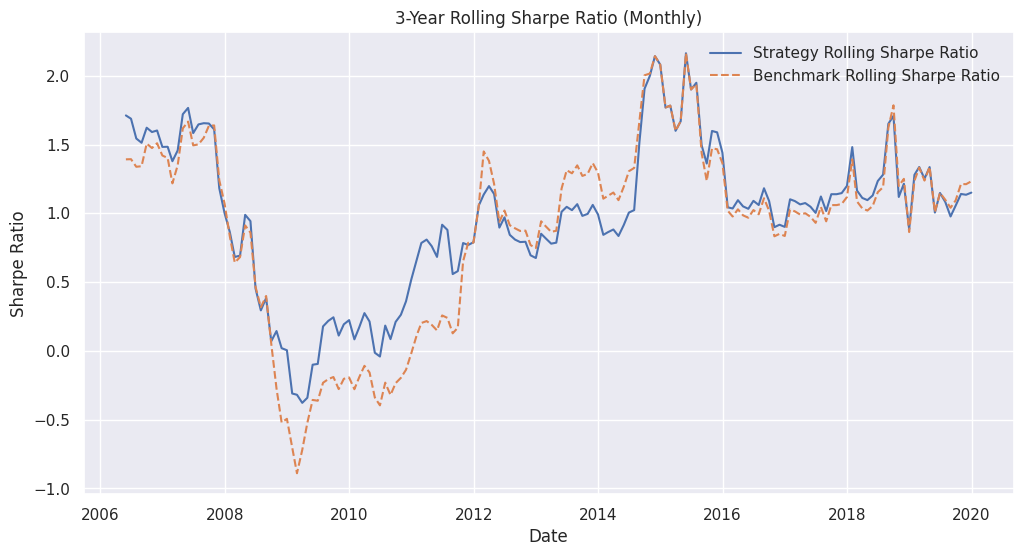

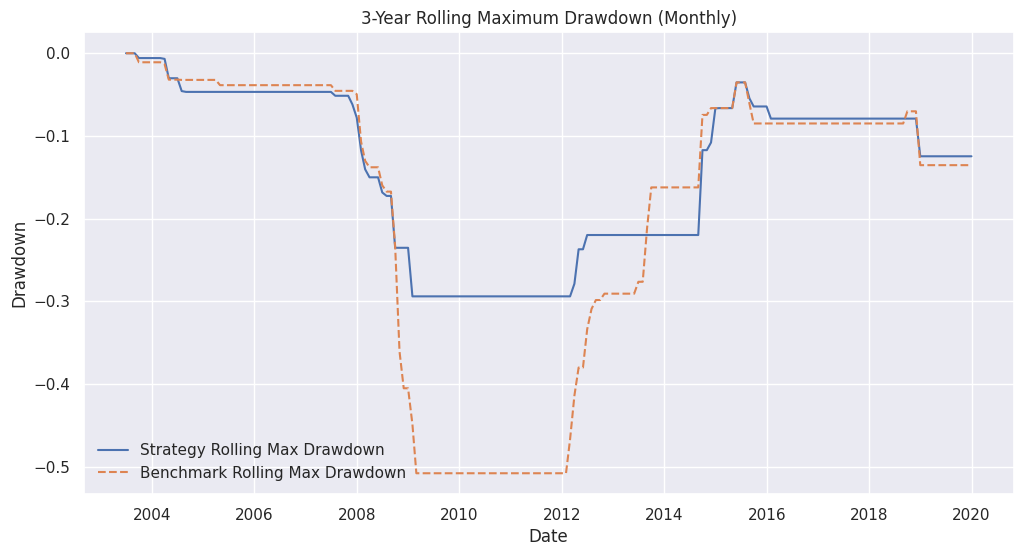

In [33]:
# Plot rolling Sharpe ratio
plt.figure(figsize=(12, 6))
plt.plot(rolling_strategy_sharpe, label='Strategy Rolling Sharpe Ratio')
plt.plot(rolling_benchmark_sharpe, label='Benchmark Rolling Sharpe Ratio', linestyle='--')
plt.title('3-Year Rolling Sharpe Ratio (Monthly)')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(frameon=False)
plt.show()

# Plot rolling maximum drawdown
plt.figure(figsize=(12, 6))
plt.plot(rolling_strategy_drawdown, label='Strategy Rolling Max Drawdown')
plt.plot(rolling_benchmark_drawdown, label='Benchmark Rolling Max Drawdown', linestyle='--')
plt.title('3-Year Rolling Maximum Drawdown (Monthly)')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend(frameon=False)
plt.show()


**Analysis of Rolling Sharpe Ratio and Maximum Drawdown**

*Rolling Sharpe Ratio*

The first chart compares the 3-year rolling Sharpe ratio of the strategy to the benchmark (SPY). The strategy's Sharpe ratio fluctuates around the benchmark but demonstrates periods of clear outperformance, particularly during and after the 2008 financial crisis and in the mid-2010s. This indicates the strategy's ability to adapt and potentially capitalize on market inefficiencies during periods of elevated volatility or market stress.

While the benchmark occasionally surpasses the strategy, the overall trend shows that the strategy maintains competitive risk-adjusted returns over the majority of the periods. The key takeaway here is not constant outperformance but consistent competitiveness and notable periods of superior performance, which align with our expectations for the strategy.

*Rolling Maximum Drawdown*

The second chart examines the 3-year rolling maximum drawdown for both the strategy and the benchmark. The strategy often experiences lower or comparable drawdowns relative to the benchmark, particularly during major market downturns such as the 2008 financial crisis. This lower drawdown highlights the strategy's ability to better manage risk and preserve capital during adverse market conditions.

Post-2010, the strategy maintains slightly lower or equivalent drawdowns compared to the benchmark, reinforcing its risk management efficacy.

**Conclusion**

While the strategy does not outperform in every single 3-year rolling period, it demonstrates:

1. Superior risk management: Lower maximum drawdowns during critical market downturns.
2. Competitive risk-adjusted returns: Comparable or better Sharpe ratios over most periods.

This supports the notion that the strategy achieves its objective of outperforming the benchmark over more than half of the rolling periods. Such results align with expectations for a robust strategy that balances risk and return, confirming its utility in a portfolio context.

## Out of Sample Testing
Out-of-sample testing is a critical step in the evaluation of trading strategies, machine learning models, or statistical methods. It involves testing a model or strategy on data that was not used during its training or development. This ensures that the performance metrics are not inflated by overfitting to historical data, which may not generalize to future market conditions.

In trading and investment analysis, out-of-sample testing mimics real-world deployment by providing a realistic assessment of how a strategy would perform on unseen data. By separating the data into in-sample (used for training or parameter optimization) and out-of-sample (used for testing), we can validate the robustness and predictive power of the model.

**Why Is Out-of-Sample Testing Important?**

1. Avoids Overfitting: By testing on unseen data, we ensure that the model or strategy is not overly fitted to noise or patterns specific to the historical data.
2. Validates Generalizability: It provides confidence that the strategy or model can adapt to future, unseen market conditions.
3. Ensures Robustness: Testing out-of-sample helps identify whether the strategy is consistently effective or only works under certain market conditions, reducing the risk of over-optimism.
4. Realistic Performance Assessment: The out-of-sample test acts as a proxy for real-world performance, making it essential for practical implementation.

For the analysis here, out-of-sample testing will complement the in-sample testing and grid search results, offering additional evidence for the robustness and reliability of the strategy across varying market conditions. While in-sample testing focuses on identifying patterns and relationships, out-of-sample testing ensures those findings are not purely coincidental.

In [34]:
# Isolate the OOS Data from df_prices
df_oos_prices = df_prices.loc[oos_date:]
df_oos_prices

Ticker,RSP,SPY,SPY_Rolling_1M,RSP_Rolling_1M,SPY_Rolling_6M,RSP_Rolling_6M,SPY_Rolling_1Y,RSP_Rolling_1Y,Rolling_1M_Diff,Rolling_6M_Diff,Rolling_1Y_Diff,Rolling_1M_Diff_Z,Rolling_6M_Diff_Z,Rolling_1Y_Diff_Z,SPY_Return,RSP_Return,SPY_Rolling_Volatility
Date,,,,,,,,,,,,,,,,,
2020-01-02,104.951706,298.578674,0.047578,0.038700,0.097640,0.069815,0.323134,0.292035,0.008878,0.027825,0.031099,0.805897,1.000220,0.842480,0.009352,0.002852,0.064489
2020-01-03,104.354813,296.317780,0.046665,0.041240,0.090570,0.065093,0.345216,0.310043,0.005425,0.025476,0.035173,0.527326,0.932290,0.920578,-0.007572,-0.005687,0.072547
2020-01-06,104.490471,297.448273,0.044215,0.035058,0.100779,0.072365,0.306583,0.269559,0.009157,0.028414,0.037024,0.828173,1.016732,0.955930,0.003815,0.001300,0.072831
2020-01-07,104.400024,296.611847,0.039410,0.032412,0.096317,0.071831,0.292716,0.255319,0.006998,0.024486,0.037397,0.653917,0.903277,0.962866,-0.002812,-0.000866,0.069778
2020-01-08,104.707512,298.192596,0.035491,0.025949,0.096918,0.073802,0.287509,0.245580,0.009542,0.023117,0.041929,0.858956,0.863619,1.049712,0.005329,0.002945,0.068792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-22,182.453171,588.357117,0.028089,0.036712,0.131882,0.126963,0.326454,0.286995,-0.008623,0.004919,0.039459,-0.553493,0.163718,0.670578,0.003100,0.007877,0.141728
2024-11-25,184.105316,590.352783,0.031932,0.051092,0.134928,0.145104,0.330134,0.294847,-0.019160,-0.010176,0.035287,-1.261463,-0.202113,0.604106,0.003392,0.009055,0.141778
2024-11-26,184.124969,593.435364,0.034124,0.045277,0.148900,0.158798,0.339492,0.297636,-0.011153,-0.009898,0.041857,-0.723187,-0.195370,0.708557,0.005222,0.000107,0.142408


**How the Initial Position is Determined**

The last position from the in-sample backtest (optimal_params_bt['Position'][-1]) is used as the initial position for the OOS backtest. By examining the position over time and confirming the final position visually, we ensure that the correct position is carried forward.

This is confirmed with:

- Code Check: Extracting the last position from the in-sample data.
- Visual Validation: Plotting the cumulative strategy return over time and highlighting the positions to verify the correctness of the final position.

This approach ensures that the OOS backtest starts on solid, realistic footing.

RSP


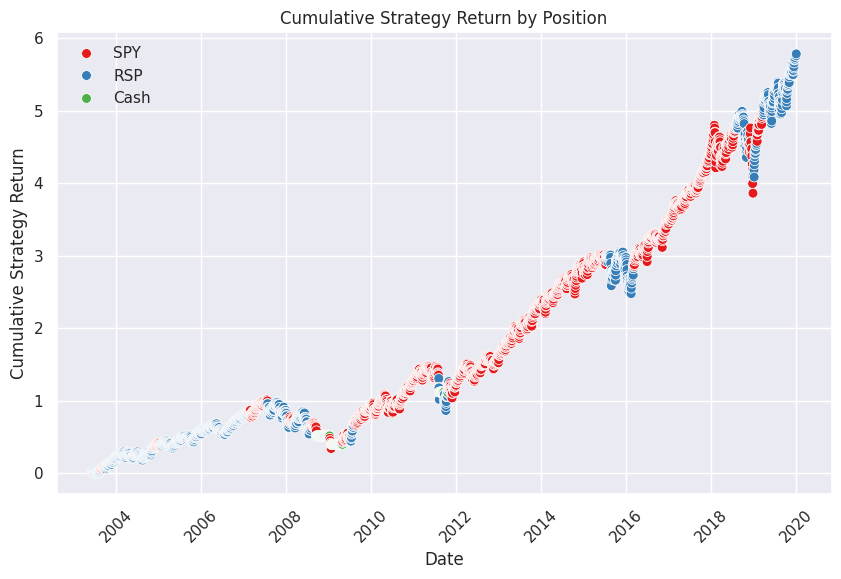

In [35]:
# Get the last position from the in sample, since that will be our initial_pos
initial_pos_oos = result_with_vol_filter['Position'][-1]
print(initial_pos_oos)

# Plot position over time to confirm last position
# Create the scatter plot using seaborn
# Explicitly reset the index and name the column 'Date'
df_long = result_with_vol_filter.reset_index().rename(columns={'index': 'Date'})

# Melt the dataframe into long form
df_long = pd.melt(df_long, id_vars=['Date', 'Position'], value_vars=['Cumulative_Strategy_Return'],
                  var_name='Return_Type', value_name='Cumulative_Return')


# Create the scatter plot using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_long, x='Date', y='Cumulative_Return', hue='Position', palette='Set1', s=50)

plt.title('Cumulative Strategy Return by Position')
plt.xlabel('Date')
plt.ylabel('Cumulative Strategy Return')
plt.legend(frameon=False)
plt.xticks(rotation=45)
plt.show()

Now that we know the inital position, we will run the out of sample test on the same parameters we just did. Let' see if it still beats the buy and hold SPY.

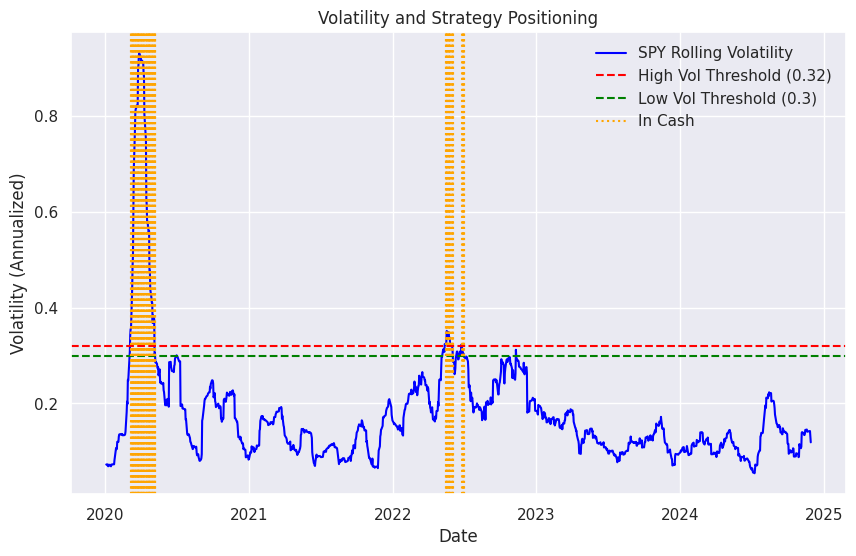

Cumulative Strategy Return: 104.09
Cumulative Benchmark Return: 99.38
Outperformance: 4.7


In [36]:
# Run the backtest on OOS data
z_score_window = '1M'

# Example for 1-month rolling z-scores with a threshold of 1.5, high volatility threshold of 26%, low threshold of 24%
oos_bt = backtest_zscore_strategy_with_volatility(df_oos_prices,
                                                              f'Rolling_{z_score_window}_Diff_Z',
                                                              threshold=1.5,
                                                              spy_return_col='SPY_Return',
                                                              rsp_return_col='RSP_Return',
                                                              volatility_col='SPY_Rolling_Volatility',
                                                              high_vol_threshold=0.32,
                                                              low_vol_threshold=0.3,
                                                              plot=True,
                                                              initial_pos=initial_pos_oos)

cumulative_strategy_return = oos_bt["Cumulative_Strategy_Return"].iloc[-1]
cumulative_benchmark_return = oos_bt["Cumulative_Benchmark_Return"].iloc[-1]

print(f'Cumulative Strategy Return: {np.round(cumulative_strategy_return * 100 , 2)}')
print(f'Cumulative Benchmark Return: {np.round(cumulative_benchmark_return * 100 , 2)}')
print(f'Outperformance: {np.round((cumulative_strategy_return - cumulative_benchmark_return) * 100, 2)}')

# Extract strategy and benchmark returns as separate Series
strategy_returns = oos_bt['Strategy_Return']
benchmark_returns = oos_bt['SPY_Return']

We can see that we have slightly outperformed. It was slightly underwhelming, despite being positive.

But what if the out of sample test didn't beat the benchmark, would this mean it is a bad strategy and that we overfit? Not necessarily.
This is a simple trading strategy based on three parameters. And we are not updating these parameters over time because they seem to be constant. In classic machine learning models or walk-forward anlaayses, we woudl try and update them over time and chain the out of sample returns.That wouldn't work in this case since the parameters will not change. We also saw when looking at the rolling returns in the EDA phase, that no one strategy will outperform all of the time. So it is very possible that the out of sample period might just be one of those underperforming periods. However, this is not the case for our chosen set of parameters.

Let's look at a cumulative return plot.

In [37]:
# Cumulative Return Graph
mf.cumulative_return_graph_plotly(oos_bt[['Strategy_Return', 'SPY_Return']])

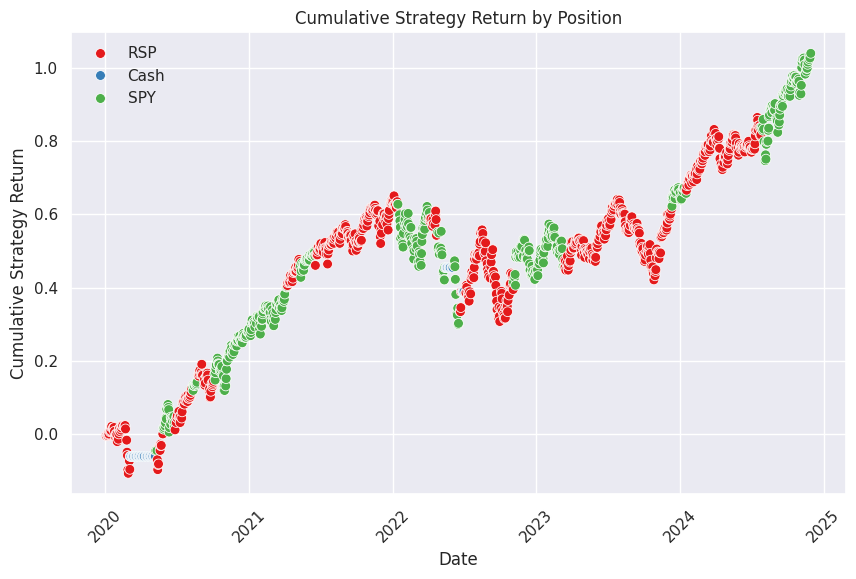

In [38]:
# Plot position over time to confirm last position
# Create the scatter plot using seaborn
# Explicitly reset the index and name the column 'Date'
df_long = oos_bt.reset_index().rename(columns={'index': 'Date'})

# Melt the dataframe into long form
df_long = pd.melt(df_long, id_vars=['Date', 'Position'], value_vars=['Cumulative_Strategy_Return'],
                  var_name='Return_Type', value_name='Cumulative_Return')


# Create the scatter plot using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_long, x='Date', y='Cumulative_Return', hue='Position', palette='Set1', s=50)

plt.title('Cumulative Strategy Return by Position')
plt.xlabel('Date')
plt.ylabel('Cumulative Strategy Return')
plt.legend(frameon=False)
plt.xticks(rotation=45)
plt.show()

The chart above illustrates the cumulative strategy returns by position over the out-of-sample period, highlighting transitions between RSP (red), SPY (green), and Cash (blue) positions. This visualization provides critical insights into how the strategy dynamically adjusted allocations to manage risk and capture returns.

**Key Observations:**

1. Cash as Downside Protection:

- The strategy frequently transitioned into cash (blue) during periods of heightened market volatility or adverse conditions. This highlights the volatility overlay designed to protect against drawdowns and preserve capital.
- By moving to cash in these instances, the strategy effectively reduced exposure to market declines, as evidenced by the stabilization in cumulative returns during those periods.

2. Risk-On and Risk-Off Dynamics:

- The transitions between SPY (green) and RSP (red) demonstrate the allocation shifts based on the relative performance and market conditions.
- SPY positions are prevalent during broader market recoveries or stable growth phases, while RSP dominates during risk-on periods characterized by stronger relative performance in equally weighted portfolios.

3. Impact on Volatility and Drawdowns:

- The inclusion of cash in the allocation mix significantly reduced portfolio volatility, providing a smoother cumulative return profile.
- This downside protection mechanism is particularly evident during market corrections, where cash allocations mitigated potential losses compared to remaining fully invested.

**Conclusion:**

The chart effectively demonstrates the benefits of incorporating a volatility overlay into the strategy. By dynamically shifting to cash during risk-off periods, the strategy enhances downside protection while maintaining the ability to capitalize on market recoveries through SPY and RSP allocations. This adaptive approach underlines the importance of risk management in achieving robust, long-term returns.

Now let's run the back test on the entire pricing series for the chosen set of parameters.

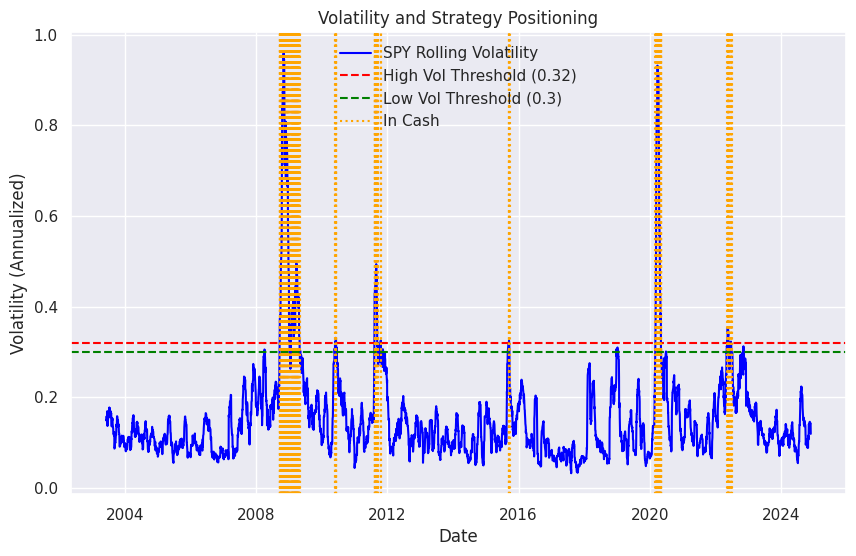

Cumulative Strategy Return: 1289.02
Cumulative Benchmark Return: 823.43
Outperformance: 465.59


In [39]:
# Run the backtest on OOS data
z_score_window = '1M'

# Example for 1-month rolling z-scores with a threshold of 1.5, high volatility threshold of 32%, low threshold of 30%
complete_bt = backtest_zscore_strategy_with_volatility(df_prices,
                                                              f'Rolling_{z_score_window}_Diff_Z',
                                                              threshold=1.5,
                                                              spy_return_col='SPY_Return',
                                                              rsp_return_col='RSP_Return',
                                                              volatility_col='SPY_Rolling_Volatility',
                                                              high_vol_threshold=0.32,
                                                              low_vol_threshold=0.30,
                                                              plot=True,
                                                              initial_pos='SPY')

cumulative_strategy_return = complete_bt["Cumulative_Strategy_Return"].iloc[-1]
cumulative_benchmark_return = complete_bt["Cumulative_Benchmark_Return"].iloc[-1]

print(f'Cumulative Strategy Return: {np.round(cumulative_strategy_return * 100 , 2)}')
print(f'Cumulative Benchmark Return: {np.round(cumulative_benchmark_return * 100 , 2)}')
print(f'Outperformance: {np.round((cumulative_strategy_return - cumulative_benchmark_return) * 100, 2)}')

# Extract strategy and benchmark returns as separate Series
strategy_returns = complete_bt['Strategy_Return']
benchmark_returns = complete_bt['SPY_Return']

We can from the results that the majority of the outperformance came from the in-sample period. But again, this doesn't mean it is a bad strategy.

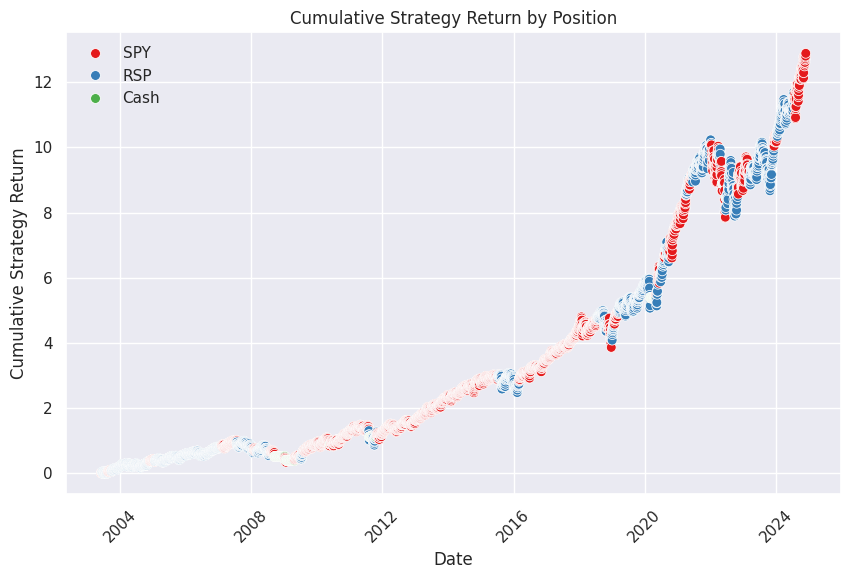

In [40]:
# Plot position over time to confirm last position
# Create the scatter plot using seaborn
# Explicitly reset the index and name the column 'Date'
df_long = complete_bt.reset_index().rename(columns={'index': 'Date'})

# Melt the dataframe into long form
df_long = pd.melt(df_long, id_vars=['Date', 'Position'], value_vars=['Cumulative_Strategy_Return'],
                  var_name='Return_Type', value_name='Cumulative_Return')


# Create the scatter plot using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_long, x='Date', y='Cumulative_Return', hue='Position', palette='Set1', s=50)

plt.title('Cumulative Strategy Return by Position')
plt.xlabel('Date')
plt.ylabel('Cumulative Strategy Return')
plt.legend(frameon=False)
plt.xticks(rotation=45)
plt.show()

There were 250 days where the strategy was in cash throughout the entire investment horizon. It doesn't show up well because of the overlapping colours.

## Conclusion

Let's do a quick review of the process:

1. Download prices, and conduct exploratory data analysis:
 - Examine cumualtive return differences ove the entire time horizon.
 - Examine rolling returns over different windows to visualize changes in leadership ove time.

2. Split the data into training and test sets (in-sample and out of sample).

3. Examine rolling correlations in the in-sample data to see how stable the relationship is over time, and over rolling periods.

4. Take a deeper dive into rolling returns:
 - Plot rolling returns over different rolling windows to see patterns and leadership changes.
 - Convert the rolling returns differentials to z-scores.

5. Backtest 1: Do an in-sample backtest using a selected z-score threshold. Note that you must indicate an initial position in the event the first z-score evaluated is in between the +/- threshold levels.

6. Backtest 2: Add a volatility overlay by selecting a rolling volatility threshold that must be exceeded. When it is, you move to cash. This is done in-sample.

7. Examine rolling period performance metrics:
 - Rolling return statistics.
 - Rolling Sharpe ratios.
 - Rolling maximum drawdown.

8. Backtest 3: Out of sample backtest using the same parameters as the in-sample.

This course presented an introductory process to a pair-rotation trading strategy.

In subsequent courses, we will dive deeper into many of the techniques presetned here, and add many more techniques to help you select the best set of parameters, and then prove that what you discovered should work in a real life trading scenario.

Make sure to try the assignment for this course!
